In [117]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 

In [118]:
mypath_origin = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/batch-1/'
mypath_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/resnet-logs-new-3/'
mypath_new = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/resnet18-logs-cpu1/'
filenames_origin = next(walk(mypath_origin), (None, None, []))[2]  # [] if no file
filenames_new = next(walk(mypath_new), (None, None, []))[2]  # [] if no file

In [119]:
hashs_origin = []
values_origin = {}
bests_origin = []
sum_origin = []
for name in filenames_origin:
    f = open(mypath_origin + name, "r")
    best = 100000
    mysum = 0
    for line in f:
        result = json.loads(line)
        task = result['i'][0][0]
        r = sum(result['r'][0])/len(result['r'][0])
        if(task not in values_origin):
            values_origin[task] = []
        if(r < best):
            best = r
        if(r < 1000):
            values_origin[task].append(r)
            mysum += r
    if(best != 100000):
        bests_origin.append(best)
        sum_origin.append(mysum)

In [120]:
hashs_new = []
values_new = {}
bests_new = []
sum_new = []
for name in filenames_new:
    f = open(mypath_new + name, "r")
    best = 100000
    mysum = 0
    for line in f:
        result = json.loads(line)
        task = result['i'][0][0]
        r = sum(result['r'][0])/len(result['r'][0])
        if(task not in values_new):
            values_new[task] = []
        if(r < best):
            best = r
        if(r < 1000):
            values_new[task].append(r)
            mysum += r
    if(best != 100000):
        bests_new.append(best)
        sum_new.append(mysum)

In [121]:
speedup = []
speedup_sum = []
for idx, value in enumerate(bests_new):
    print(bests_origin[idx], bests_new[idx], bests_origin[idx]/bests_new[idx])
    print(sum_origin[idx], sum_new[idx], sum_origin[idx]/sum_new[idx])
    if(sum_origin[idx]/sum_new[idx] < 5851):
        speedup.append(bests_origin[idx]/bests_new[idx])
        speedup_sum.append(sum_origin[idx]/sum_new[idx])

0.01026458 0.0004923170000000001 20.849533938498972
8.202470554000001 0.07834817760000004 104.69255067906005
0.000454527 0.0004880894 0.9312371872857718
1.6004469082999992 0.0952126396 16.809185366813413
0.00020041689999999995 3.29709e-05 6.078599613598657
0.6867066432000009 0.006426048199999997 106.86297734274716
0.00046895 0.0004844395 0.9680259351270902
1.6763977384 0.08032870290000003 20.86922454713257
0.00039423979999999995 1.9537000000000003e-05 20.1791370220607
1.2862259577000001 0.03356559319999999 38.31977436049009
0.00040163279999999997 2.8991800000000003e-05 13.853324043350186
1.7009387535999976 0.004874438199999996 348.95072699865165
0.0003134291 4.0092e-06 78.17746682629951
1.371704636600003 0.00015046050000000003 9116.70927984423
2.6968599999999998e-05 0.00023404810000000003 0.11522674185349077
0.09966704449999995 0.09100851169999995 1.095139813169805
0.0004343495 0.0002681069 1.6200608787017419
1.1699895915000011 0.15890861699999997 7.36265668651563
3.0570799999999995e-0

<BarContainer object of 16 artists>

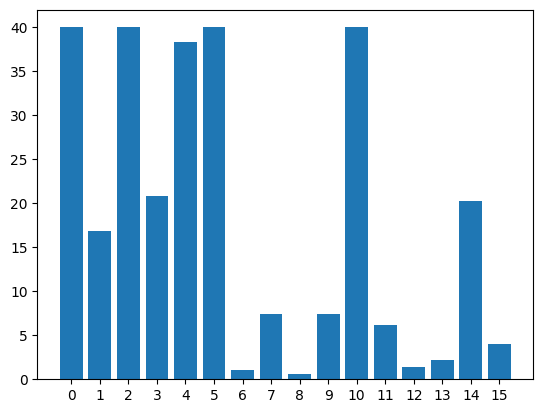

In [122]:
x = []
for v in np.arange(len(speedup_sum)):
    x.append(str(v))
for idx in range(len(speedup_sum)):
    if(speedup_sum[idx] > 40):
        speedup_sum[idx] = 40
plt.bar(x, speedup_sum)

In [123]:
speedup_sum

[40,
 16.809185366813413,
 40,
 20.86922454713257,
 38.31977436049009,
 40,
 1.095139813169805,
 7.36265668651563,
 0.6160970180666389,
 7.458622043156731,
 40,
 6.113108001285541,
 1.4290096261396006,
 2.187896061809013,
 20.211127009825045,
 4.05209983365235]

<BarContainer object of 16 artists>

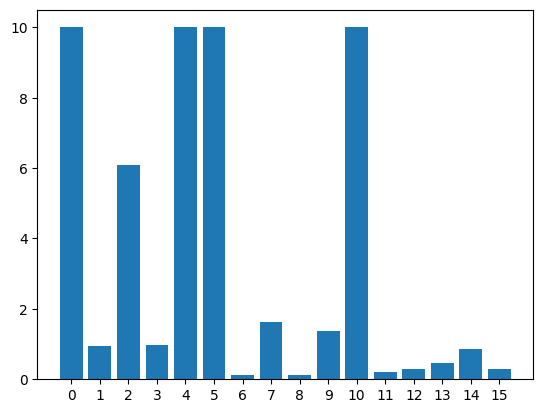

In [125]:
x = []
for v in np.arange(len(speedup)):
    x.append(str(v))
for idx in range(len(speedup)):
    if(speedup[idx] > 10):
        speedup[idx] = 10
plt.bar(x, speedup)

In [15]:
for task in values_new:
    print(task)
print()
for task in values_origin:
    print(task)

["f96117bda6ea9cbc0291c643079b3700", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64], [1, 56, 56, 64]]
["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]
["08f7449d79e570b7274174709e5e5e01", [1, 512], [1000, 512], [1, 1000], [1, 1000]]
["cb5e1bf27549411a1320749a1d8e07ca", [1, 14, 14, 256], [1, 1, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]
["d37380659057397544e056461ea3bad3", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]
["c219de5fa5fe694343f2826ebe8e47ce", [1, 112, 112, 64], [1, 56, 56, 64]]
["cb5e1bf27549411a1320749a1d8e07ca", [1, 28, 28, 128], [1, 1, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]
["8c53ca2904398da2889aa7508082d7bb", [1, 7, 7, 512], [1, 1, 1, 512]]
["07f9fcad27bdd3233f86fe35a5185d33", [1, 56, 56, 64], [3, 3, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]
["38552500208b25b4035682b0e93cbce3", [1, 14, 14, 256], [6, 6, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256]]
["4f6b116e24c389f1cf7d9a59d

["f96117bda6ea9cbc0291c643079b3700", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64], [1, 56, 56, 64]]


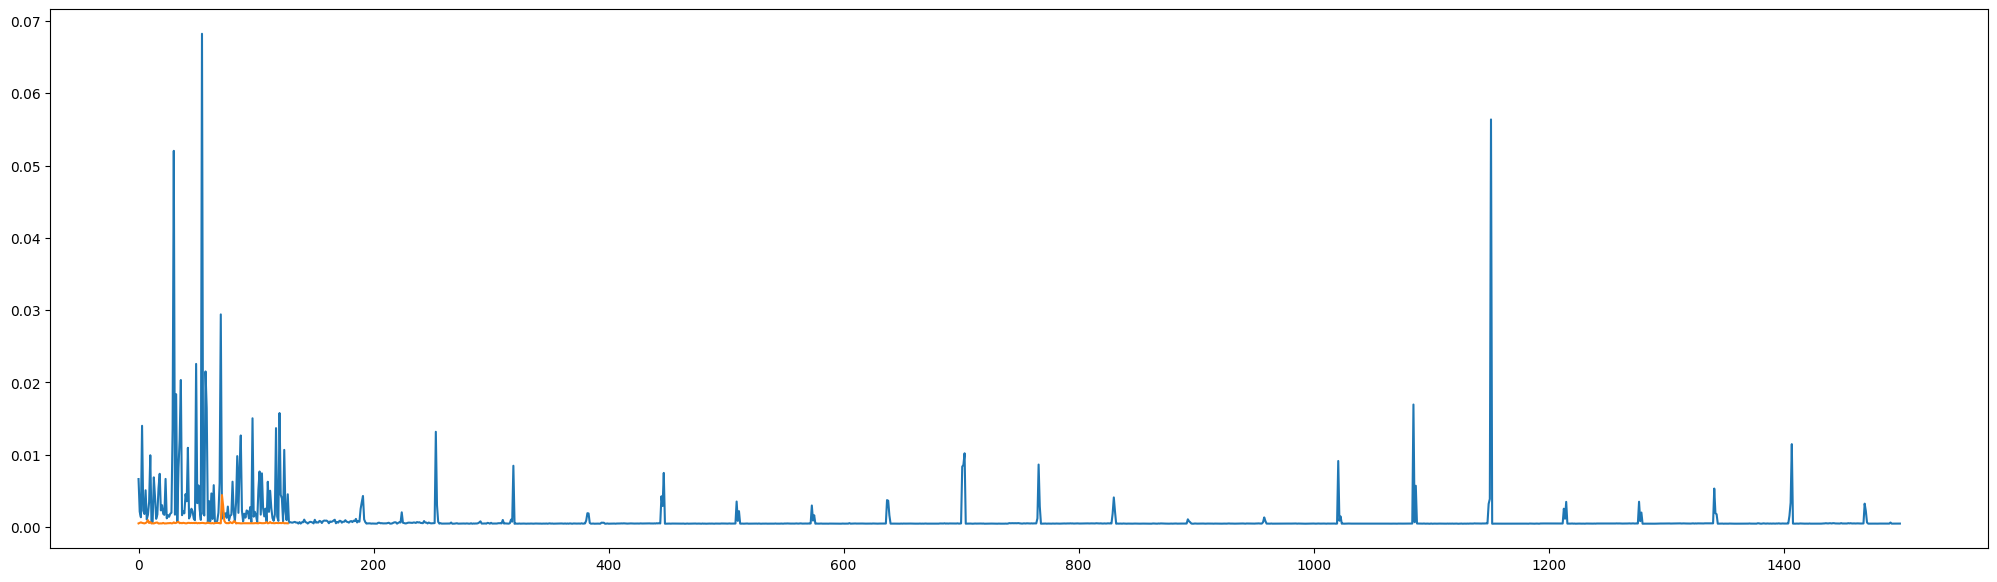

["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]


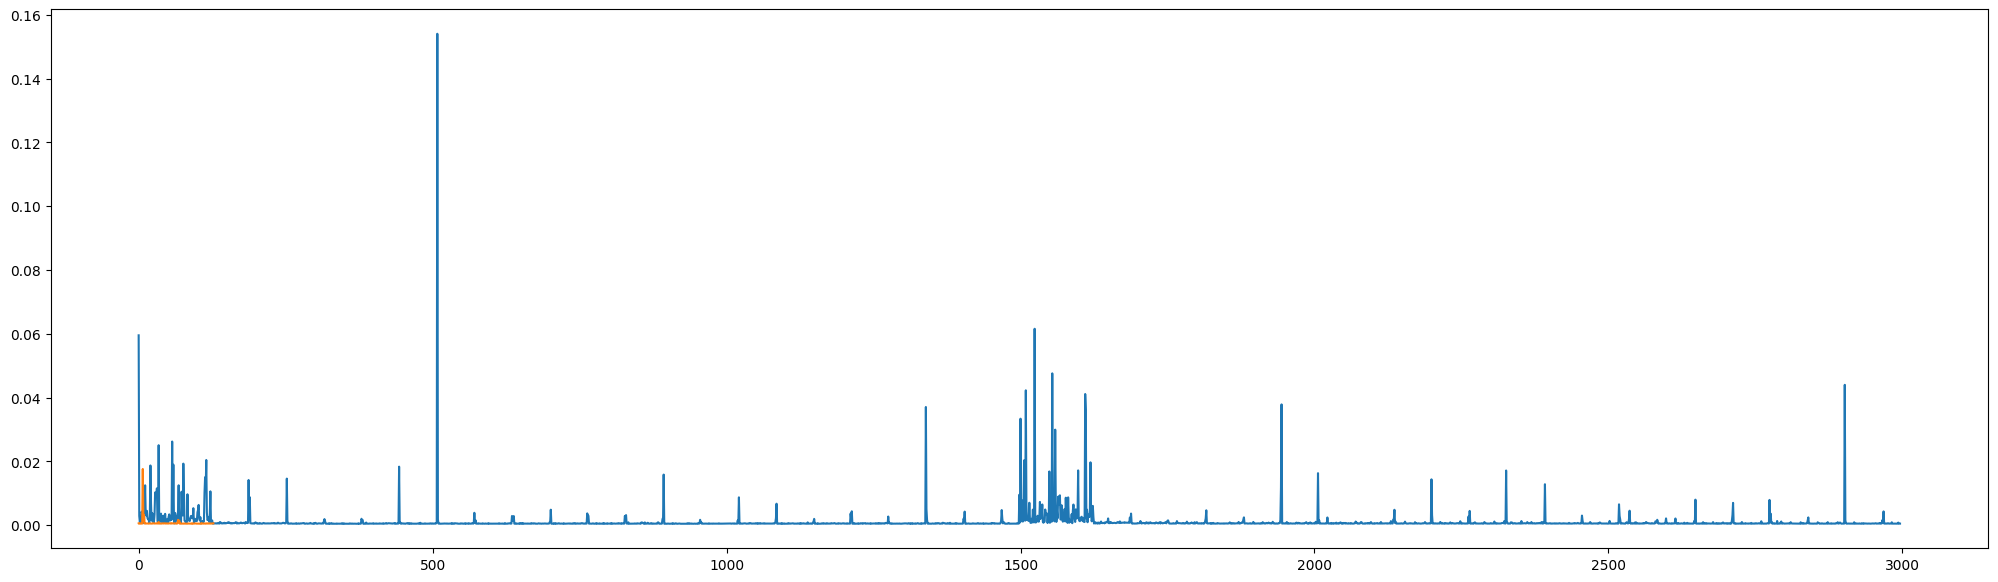

["cb5e1bf27549411a1320749a1d8e07ca", [1, 14, 14, 256], [1, 1, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


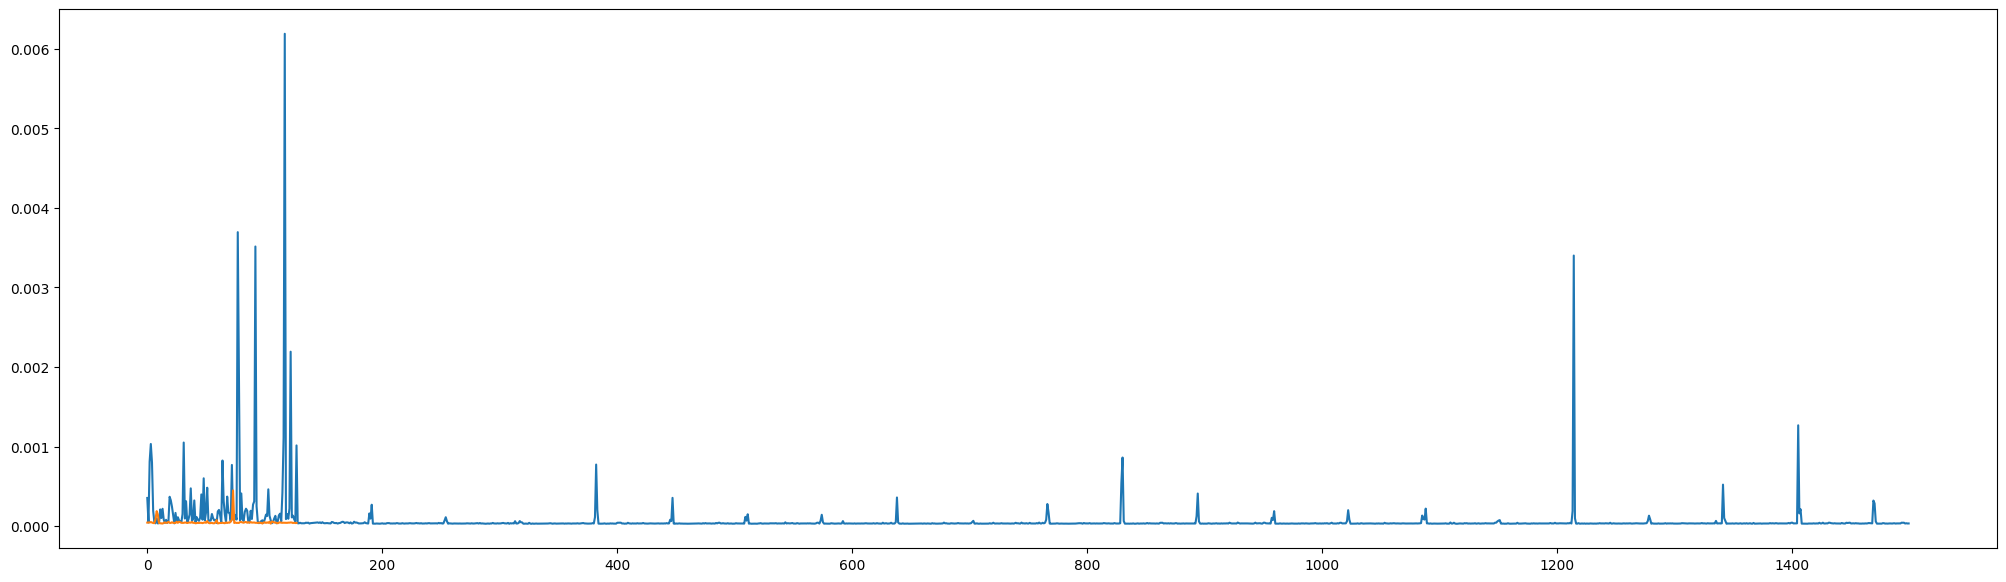

["d37380659057397544e056461ea3bad3", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]


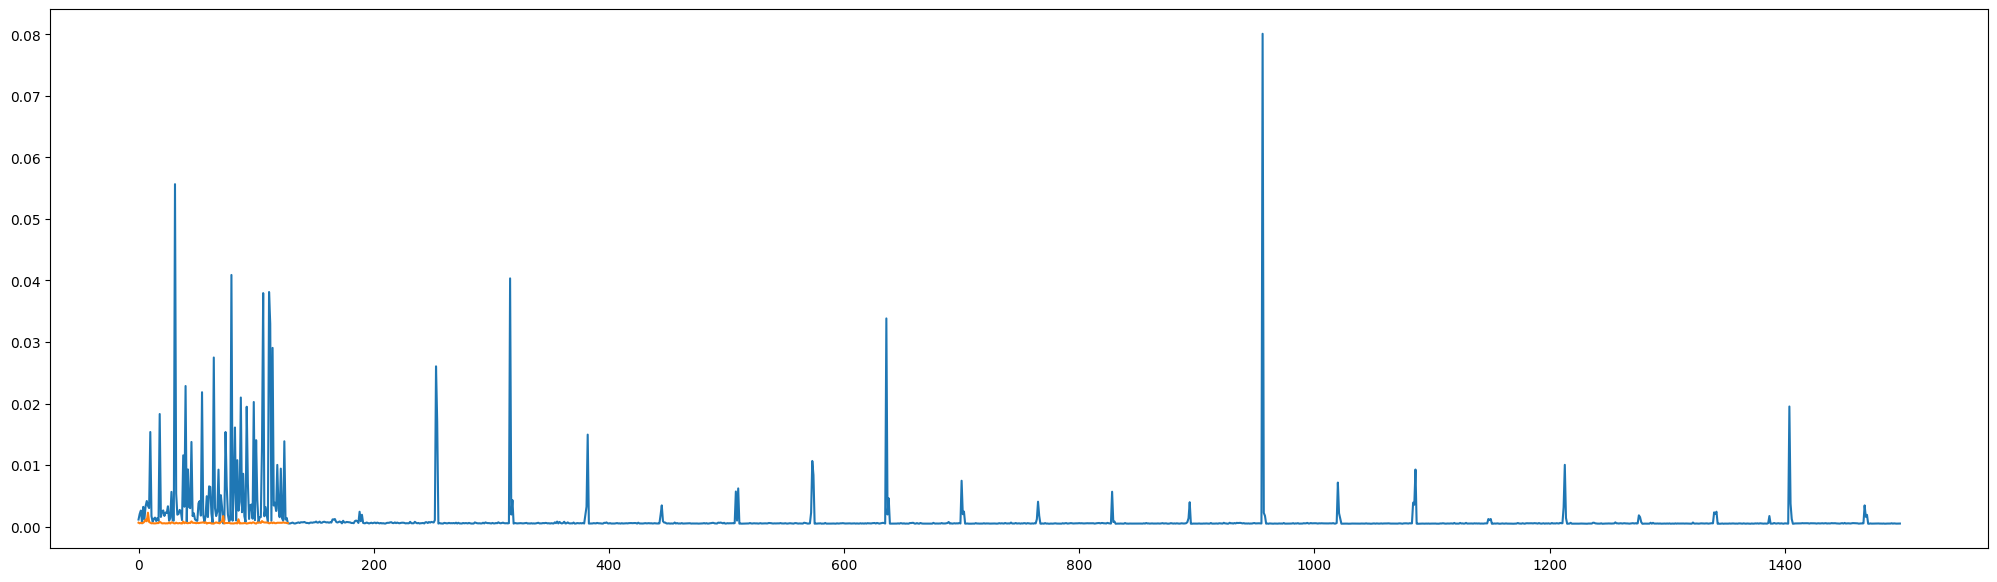

["c219de5fa5fe694343f2826ebe8e47ce", [1, 112, 112, 64], [1, 56, 56, 64]]


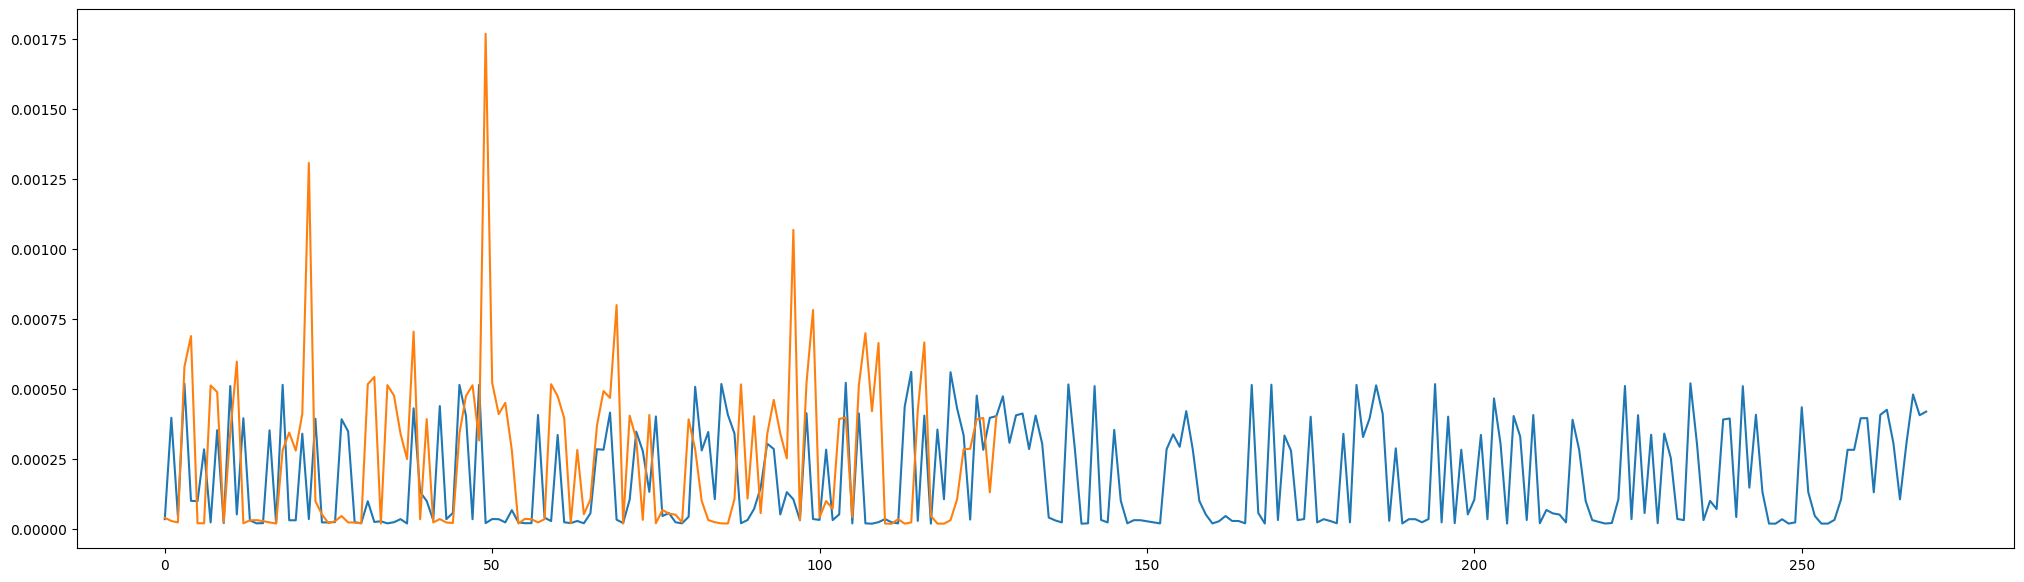

["cb5e1bf27549411a1320749a1d8e07ca", [1, 28, 28, 128], [1, 1, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


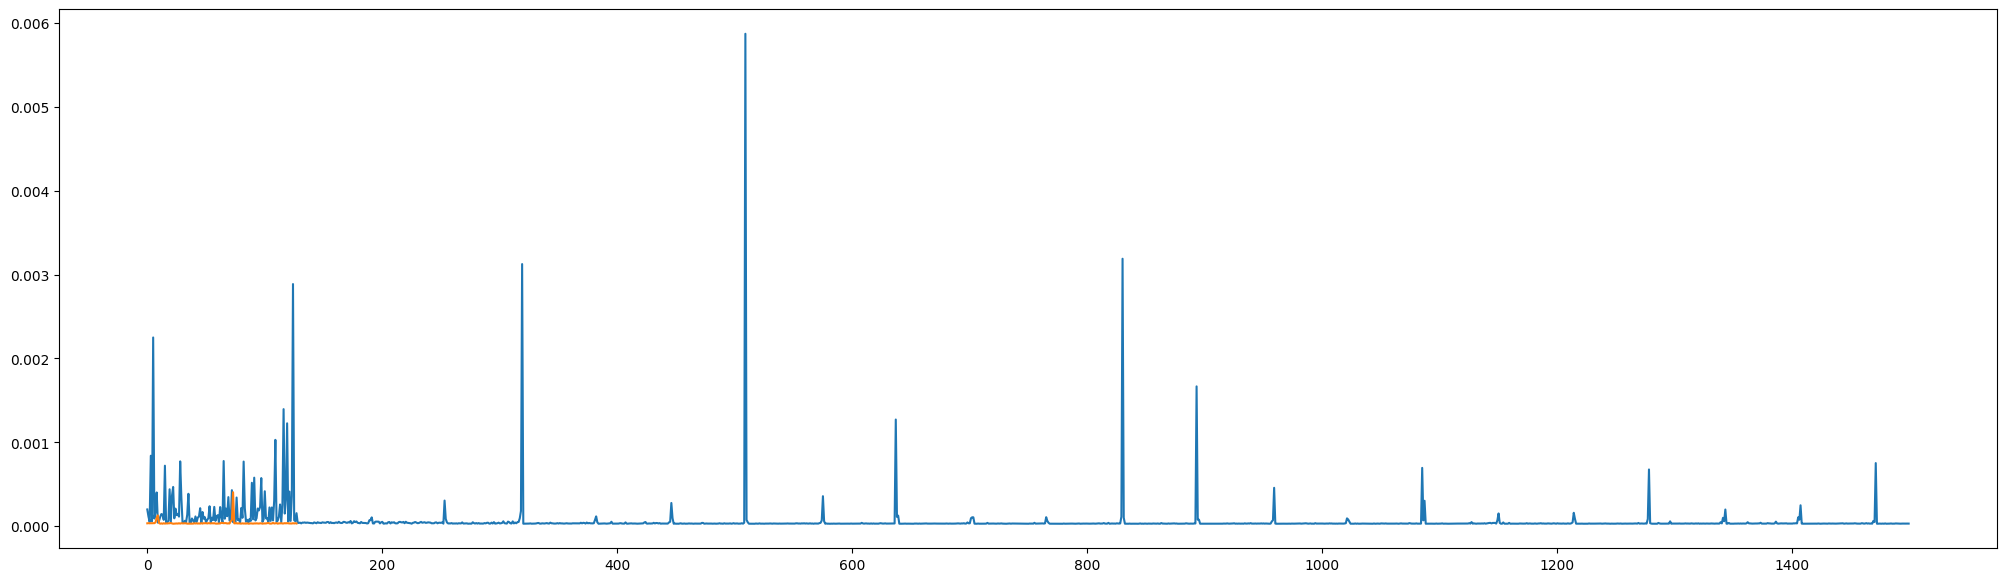

["8c53ca2904398da2889aa7508082d7bb", [1, 7, 7, 512], [1, 1, 1, 512]]


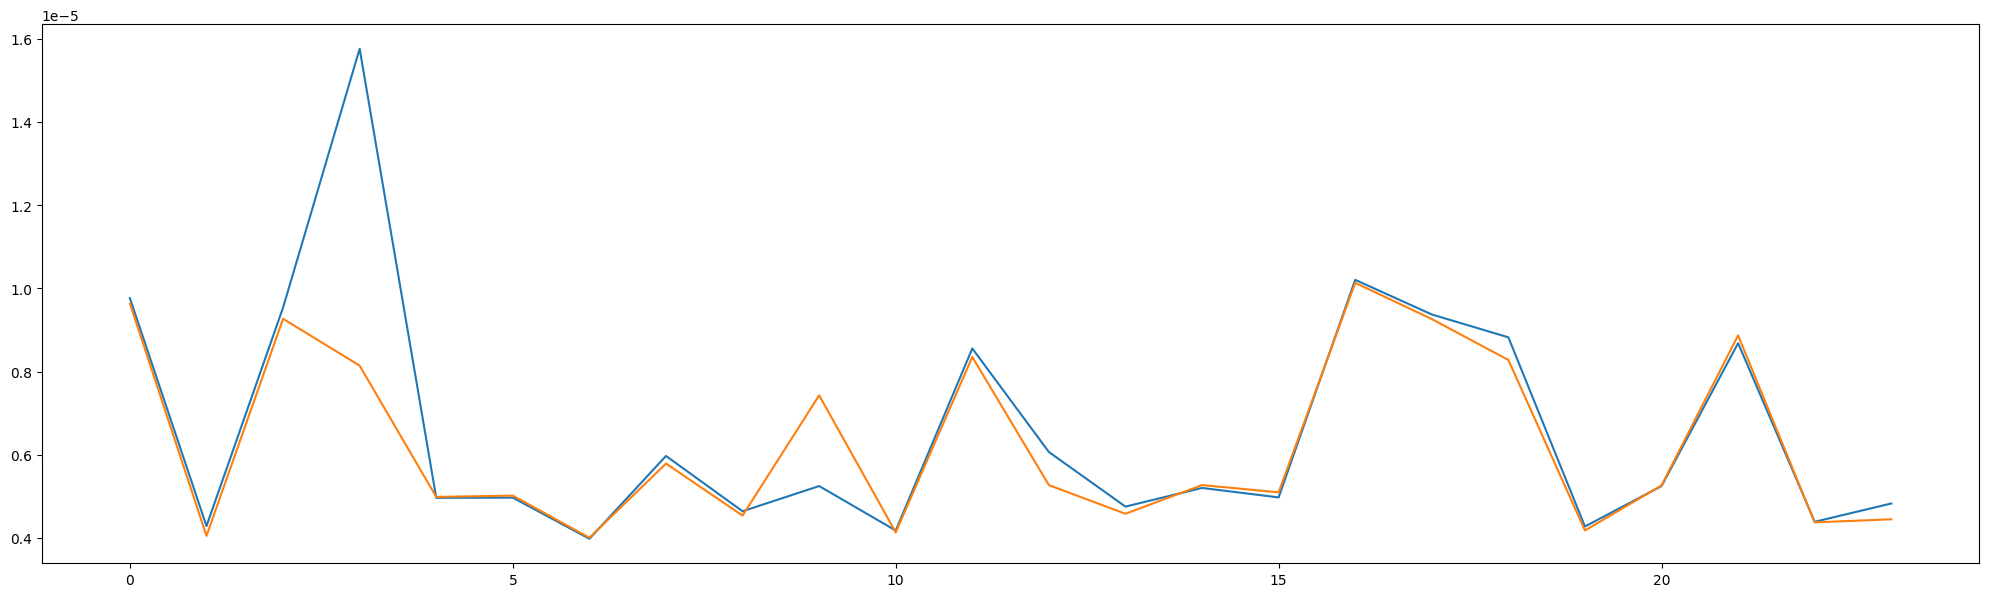

["07f9fcad27bdd3233f86fe35a5185d33", [1, 56, 56, 64], [3, 3, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


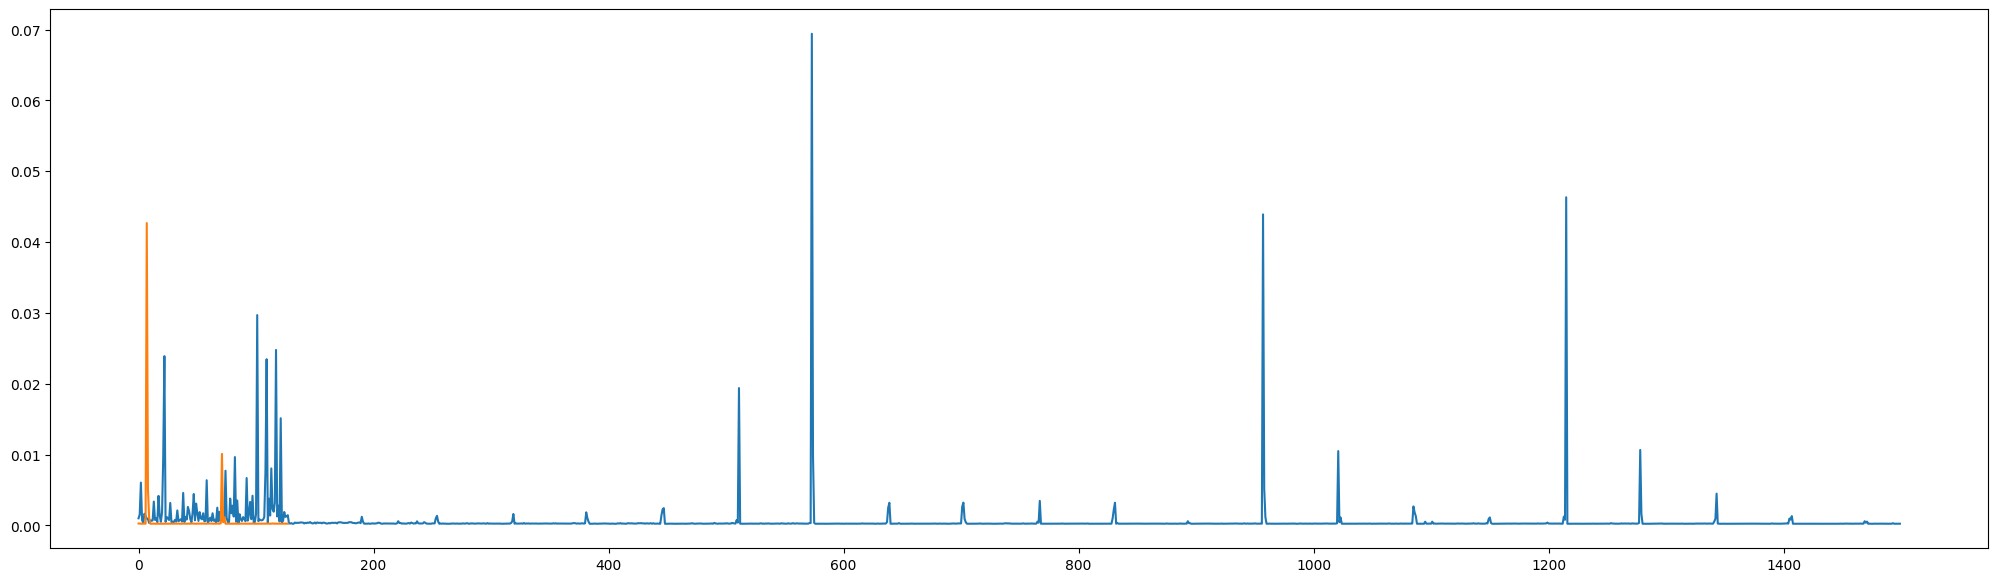

["38552500208b25b4035682b0e93cbce3", [1, 14, 14, 256], [6, 6, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


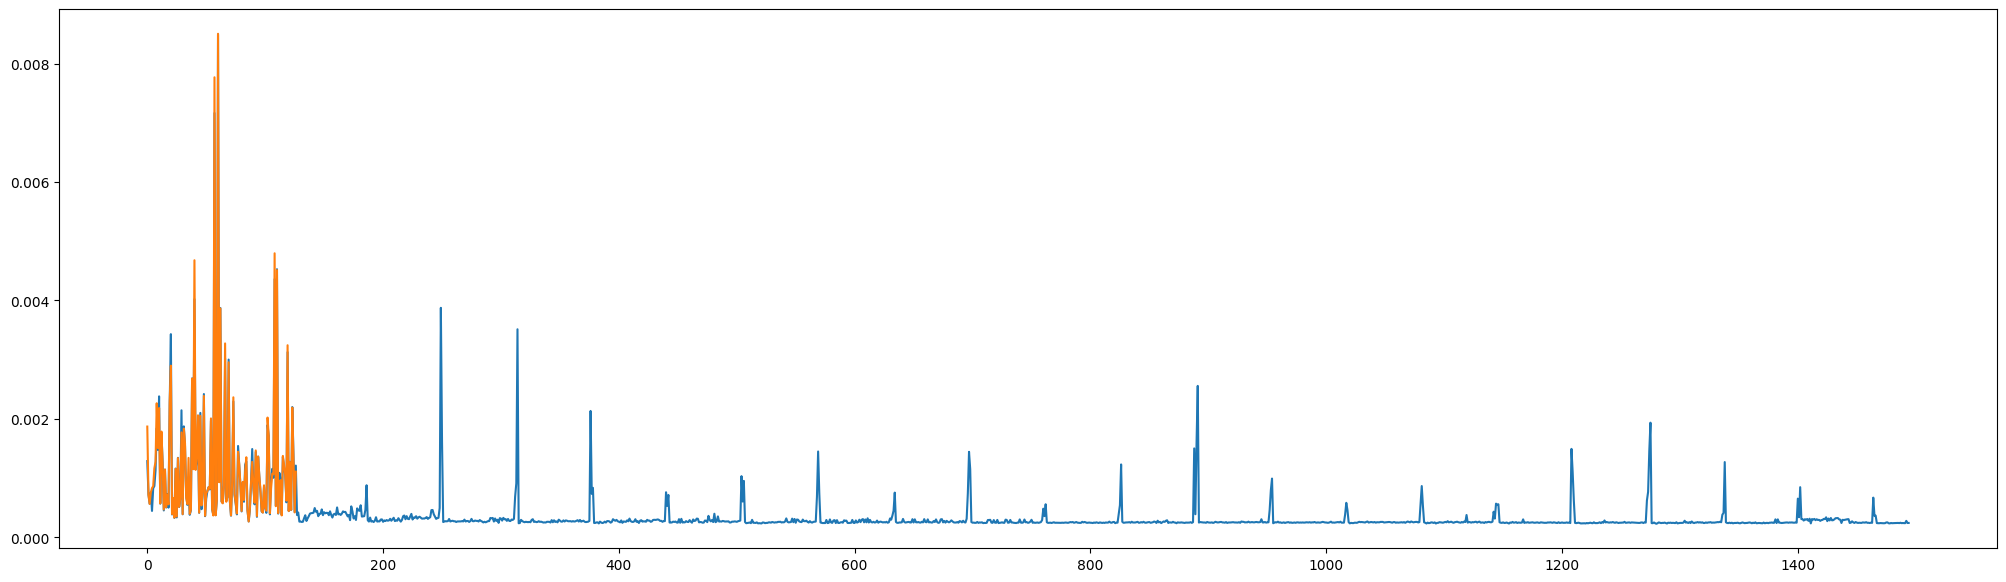

["4f6b116e24c389f1cf7d9a59da1037b4", [1, 28, 28, 128], [6, 6, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128], [1, 28, 28, 128]]


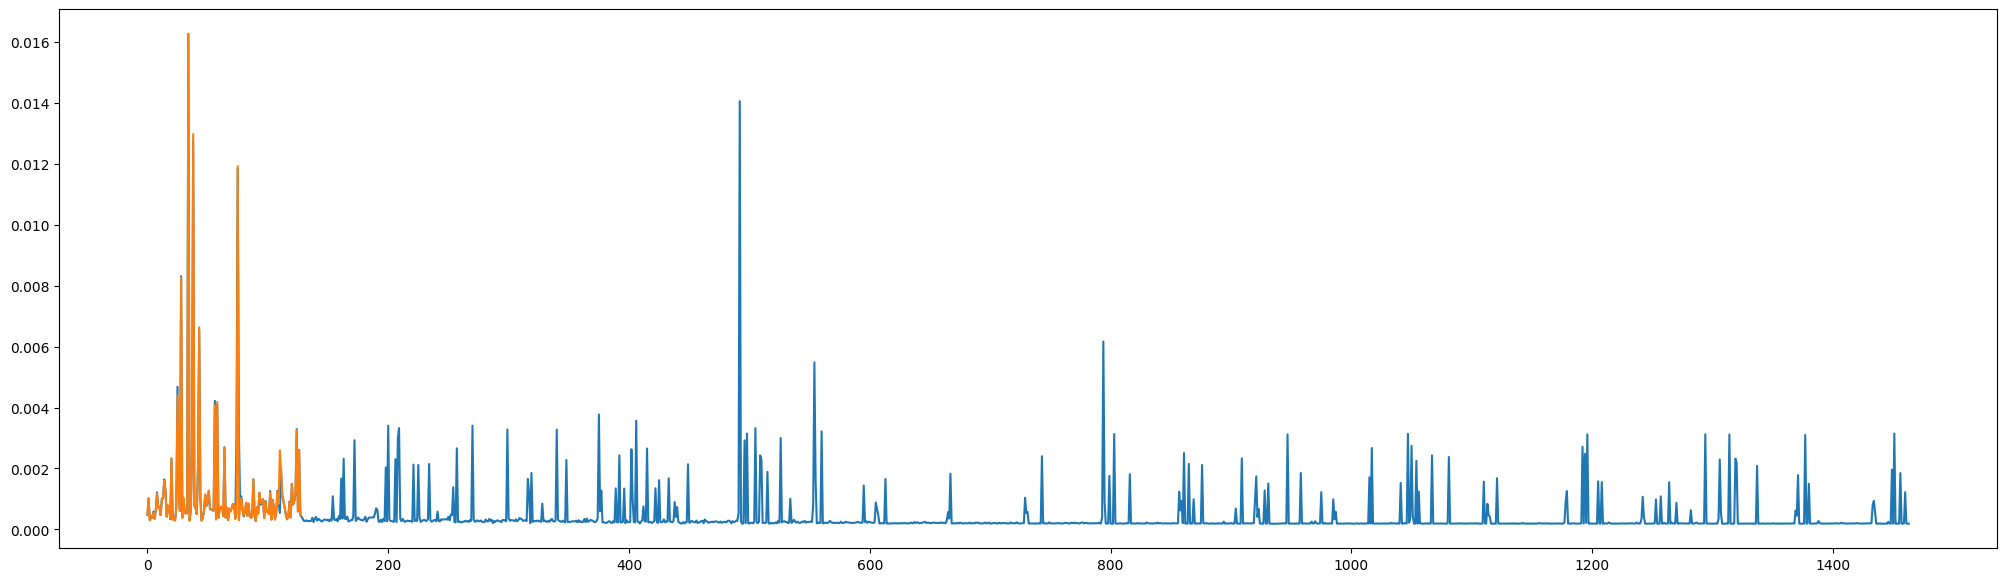

["436a540d6c3237ce2dbc4425b33d5c6d", [1, 14, 14, 256], [6, 6, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256], [1, 14, 14, 256]]


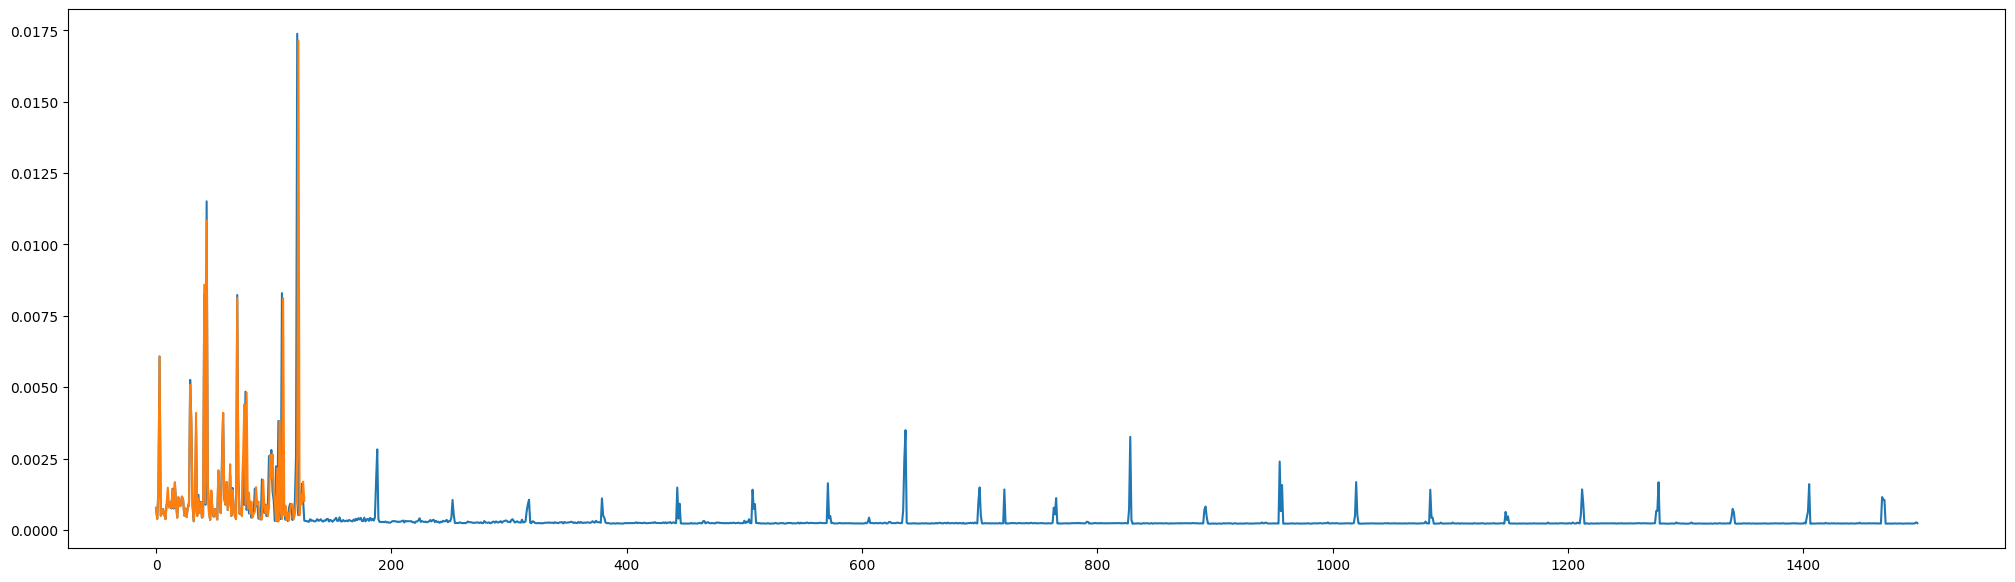

["cb5e1bf27549411a1320749a1d8e07ca", [1, 56, 56, 64], [1, 1, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


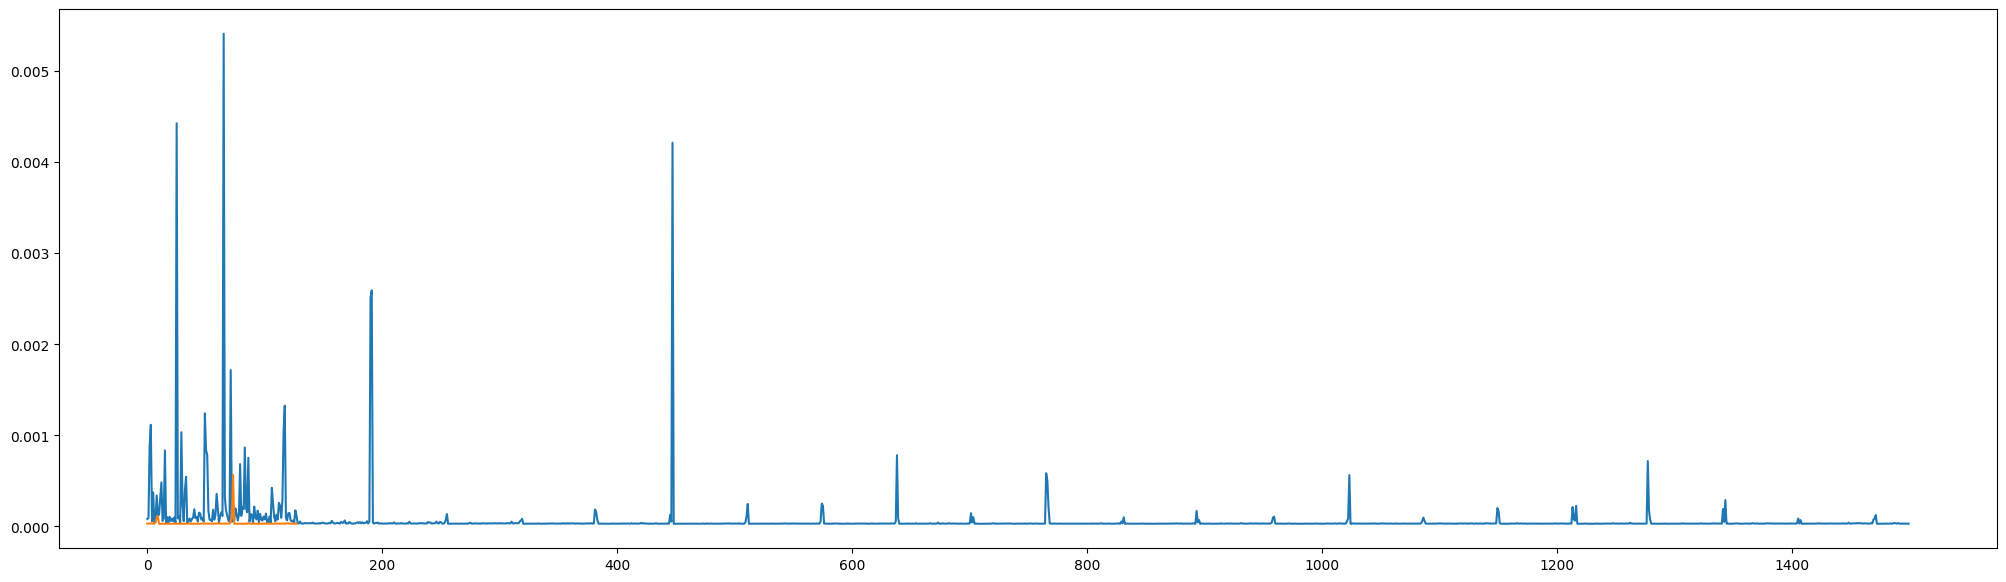

["f96117bda6ea9cbc0291c643079b3700", [1, 7, 7, 512], [3, 3, 512, 512], [1, 1, 1, 512], [1, 7, 7, 512], [1, 7, 7, 512]]


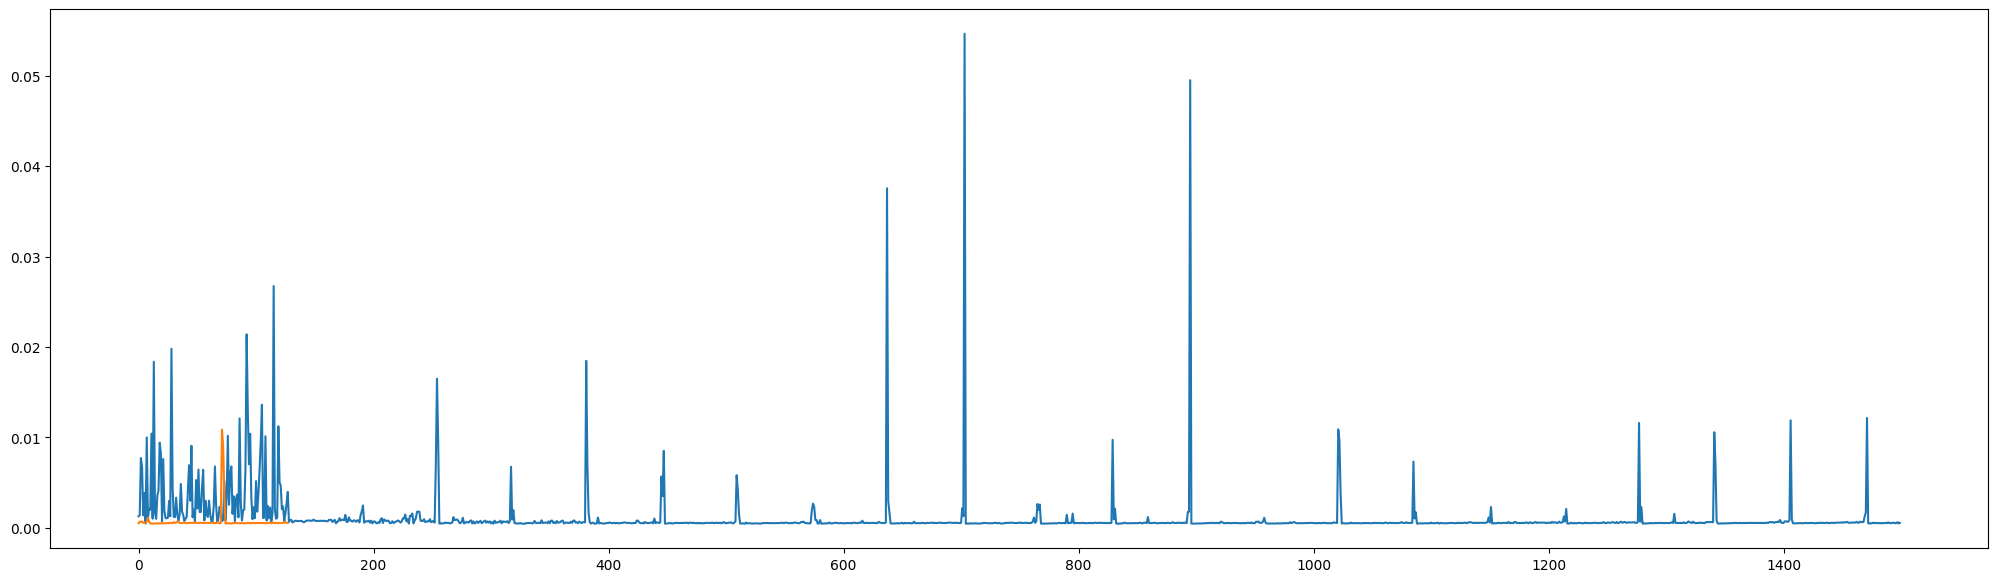

["07f9fcad27bdd3233f86fe35a5185d33", [1, 28, 28, 128], [3, 3, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]


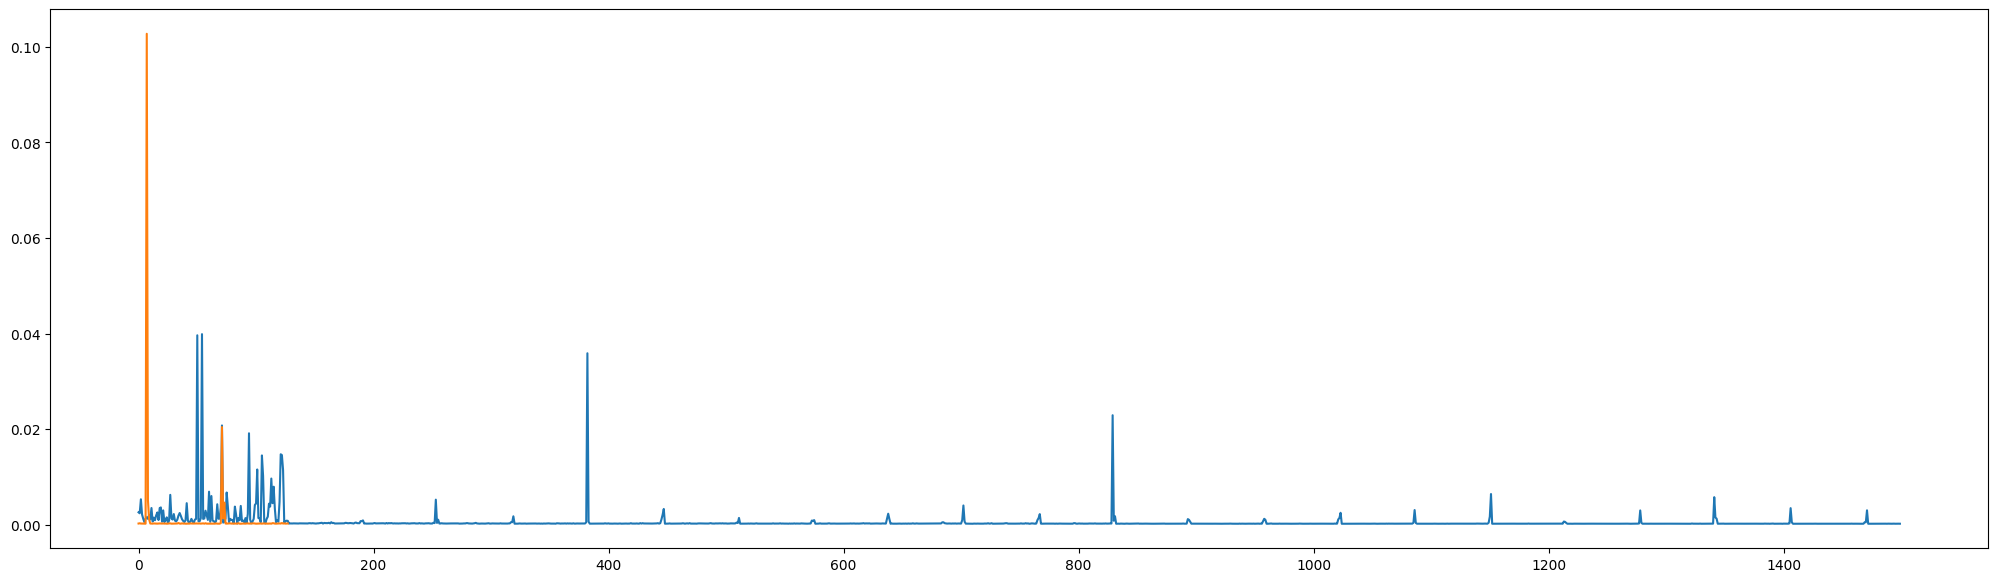

["cfd09cf1ca9e943f0ee12a18813a5c75", [1, 28, 28, 128], [6, 6, 128, 128], [1, 1, 1, 128], [1, 28, 28, 128]]


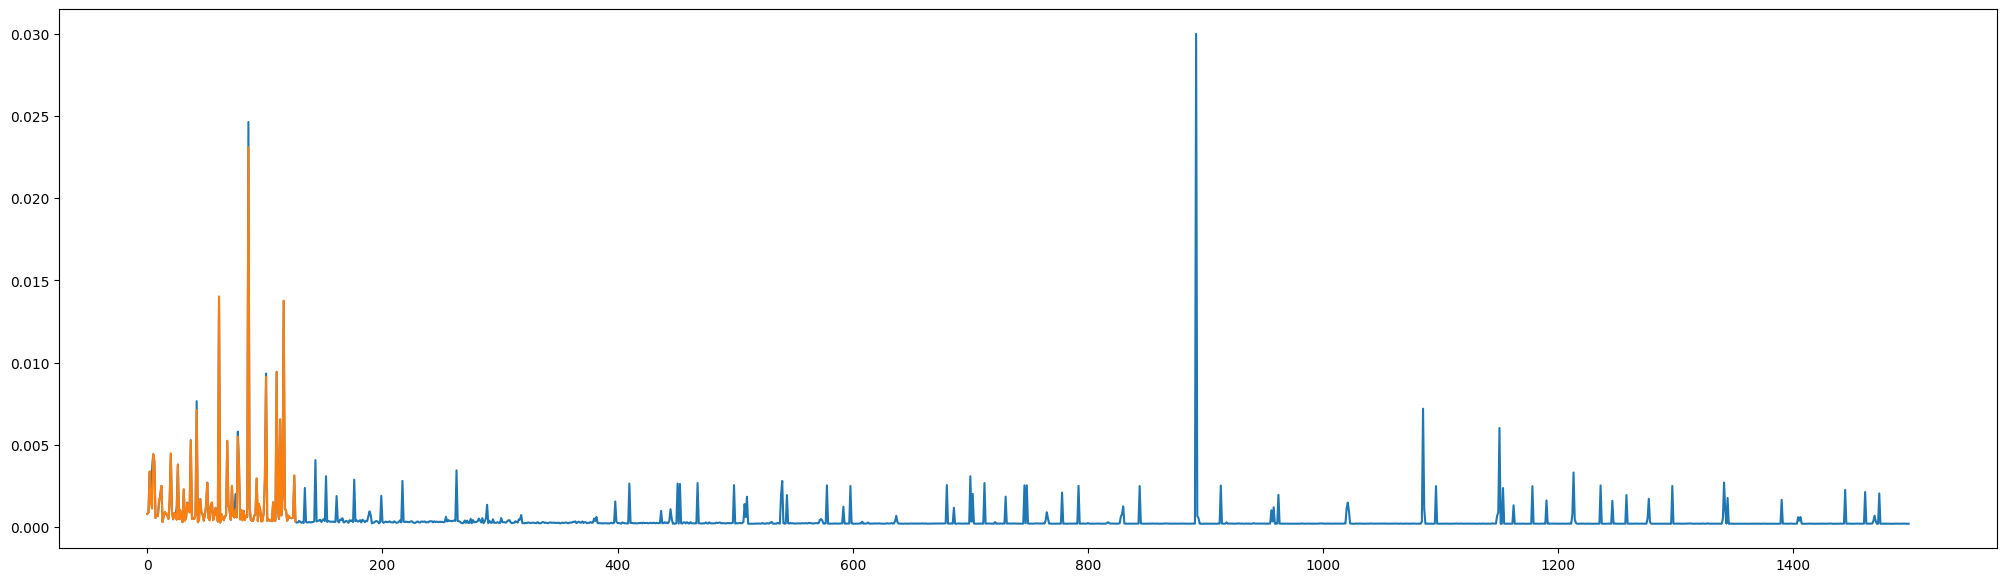

["d37380659057397544e056461ea3bad3", [1, 7, 7, 512], [3, 3, 512, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


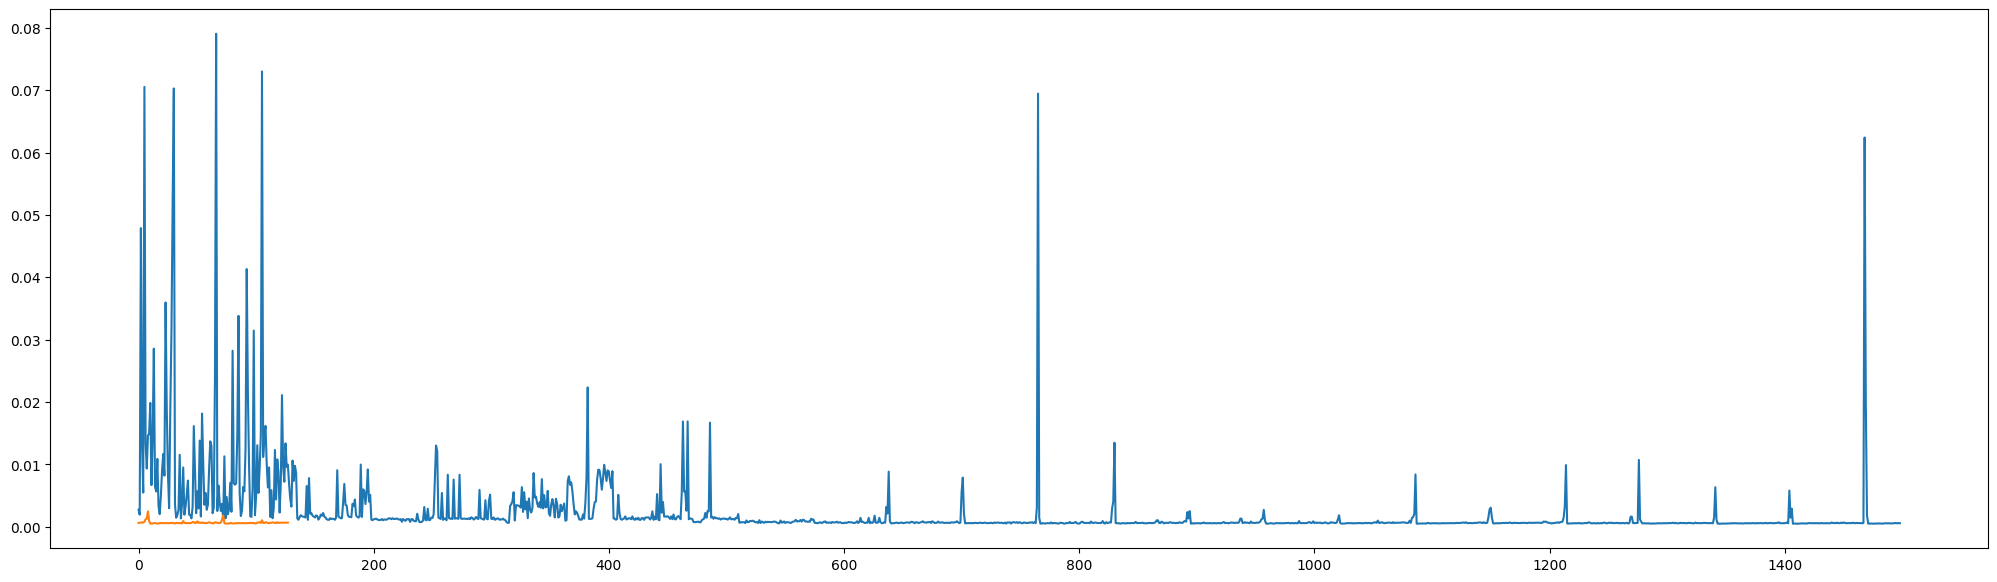

["07f9fcad27bdd3233f86fe35a5185d33", [1, 14, 14, 256], [3, 3, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]


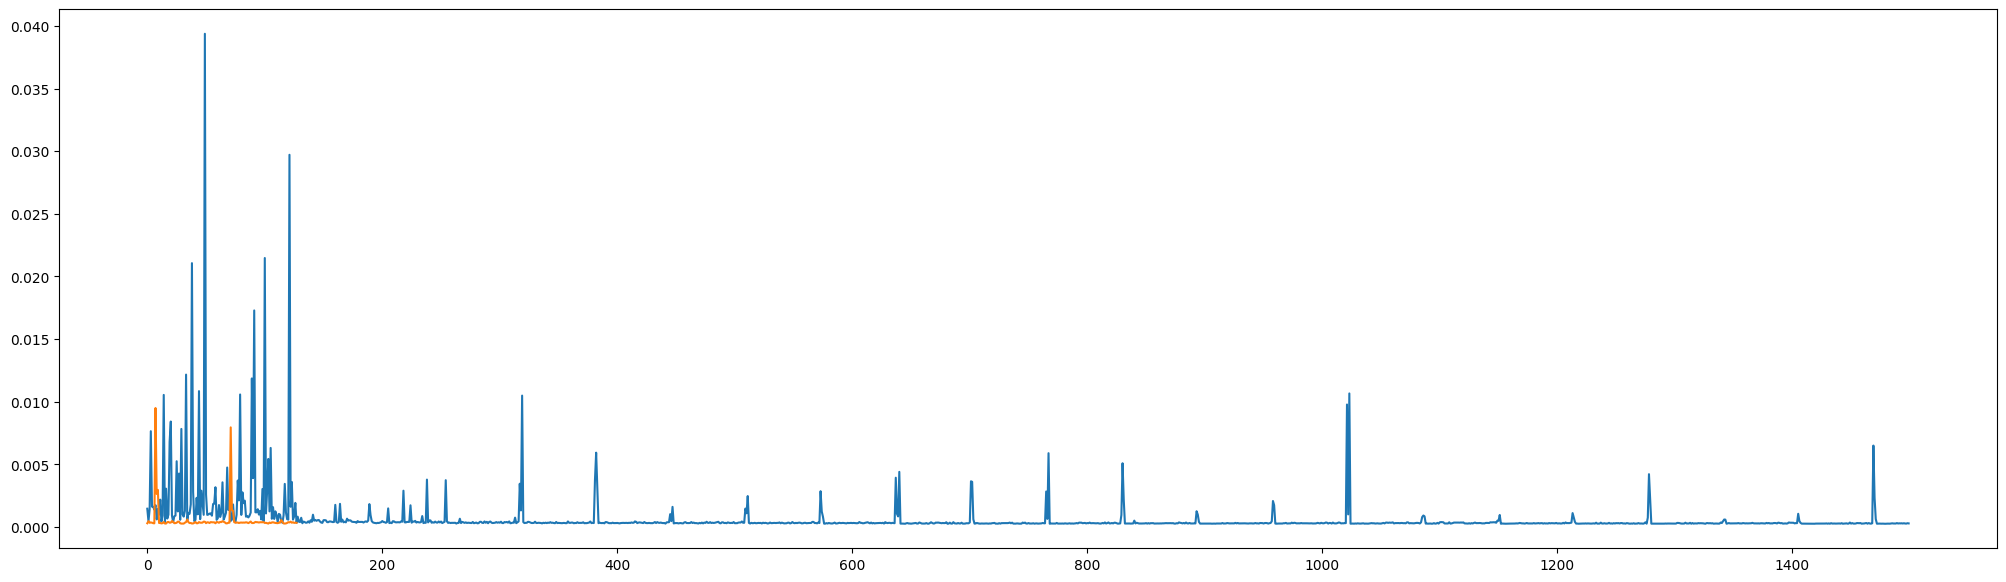

In [74]:
for idx, task in enumerate(values_new):
    if(len(values_origin[task])):
        print(task)
        plt.figure(figsize=(25, 7))
        plt.plot(values_origin[task])
        plt.plot(values_new[task])
        plt.show()

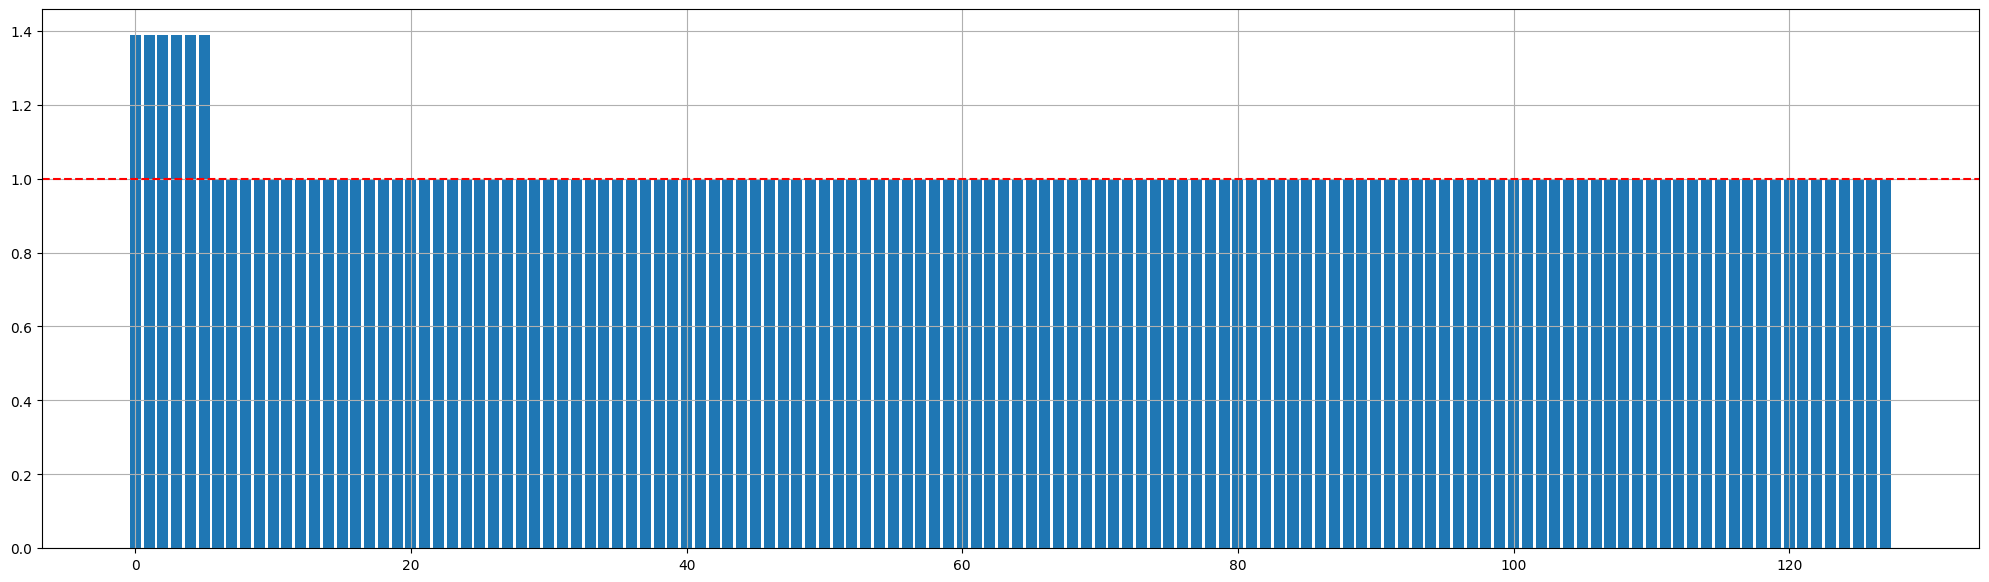

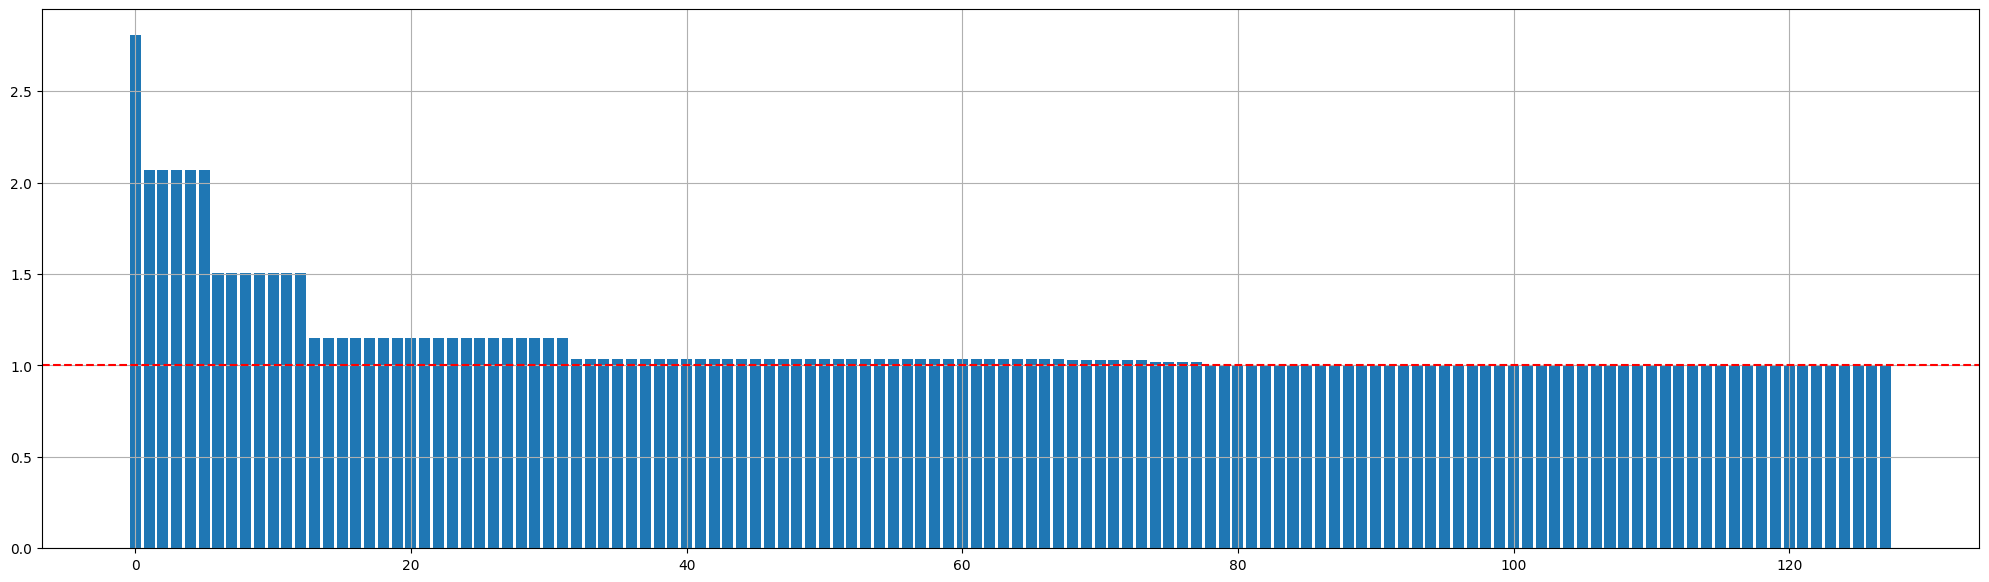

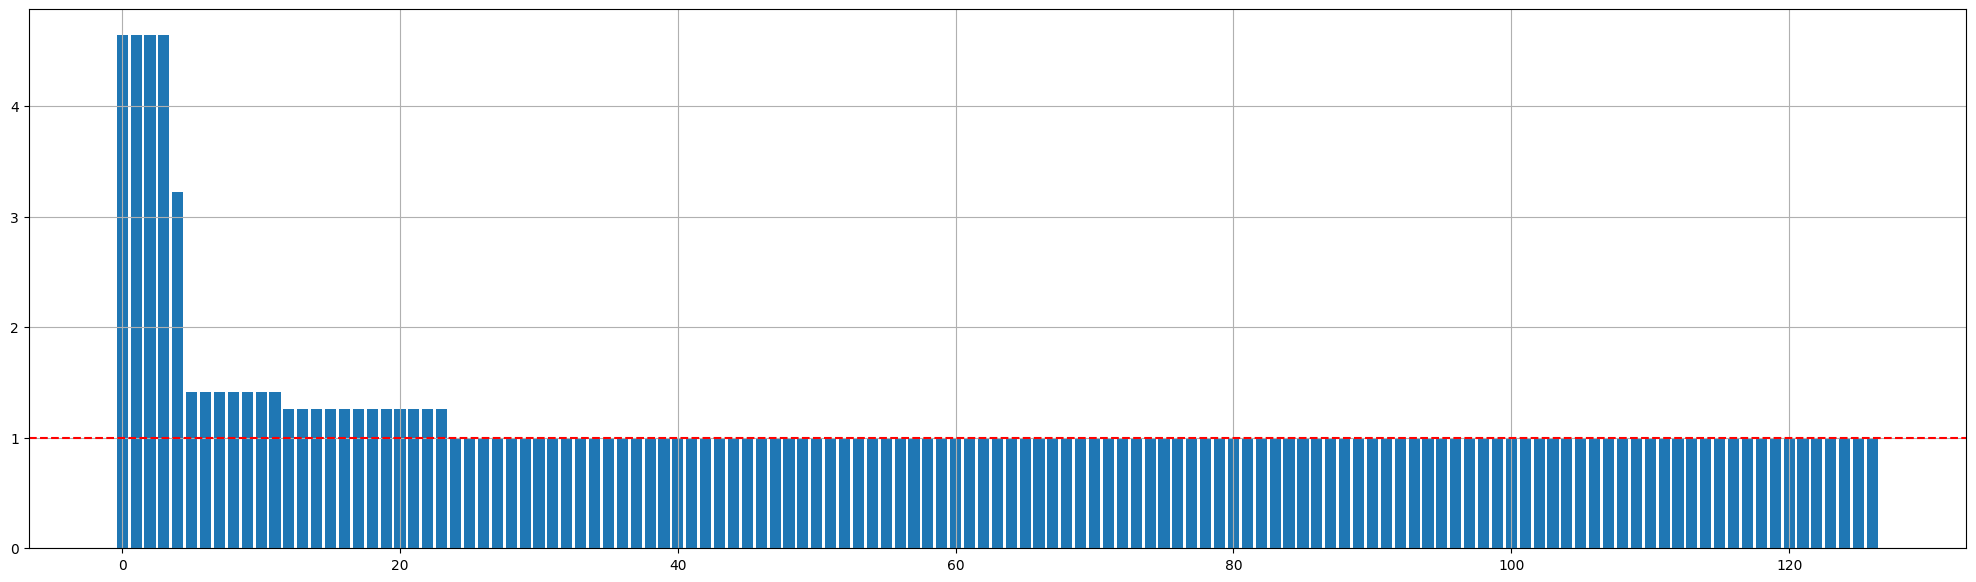

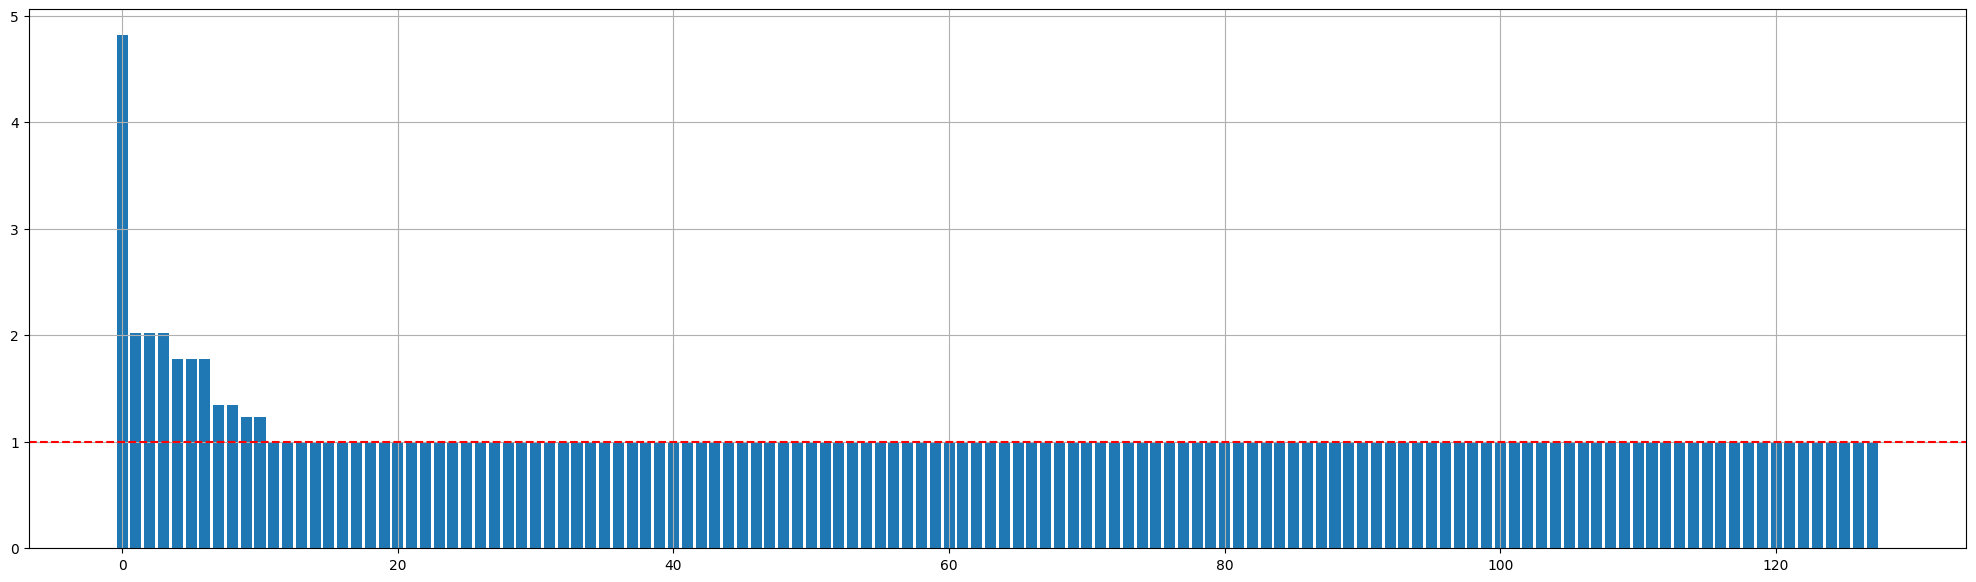

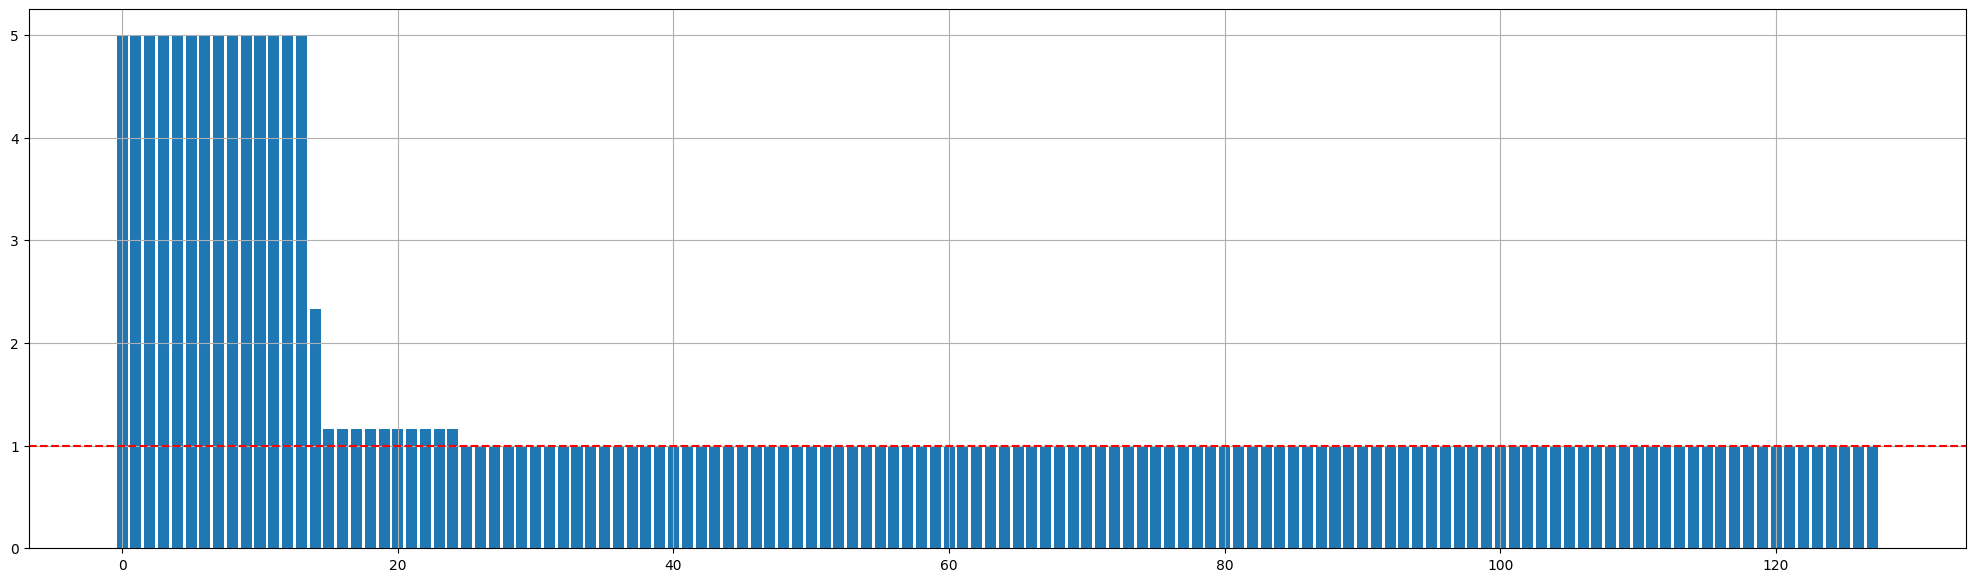

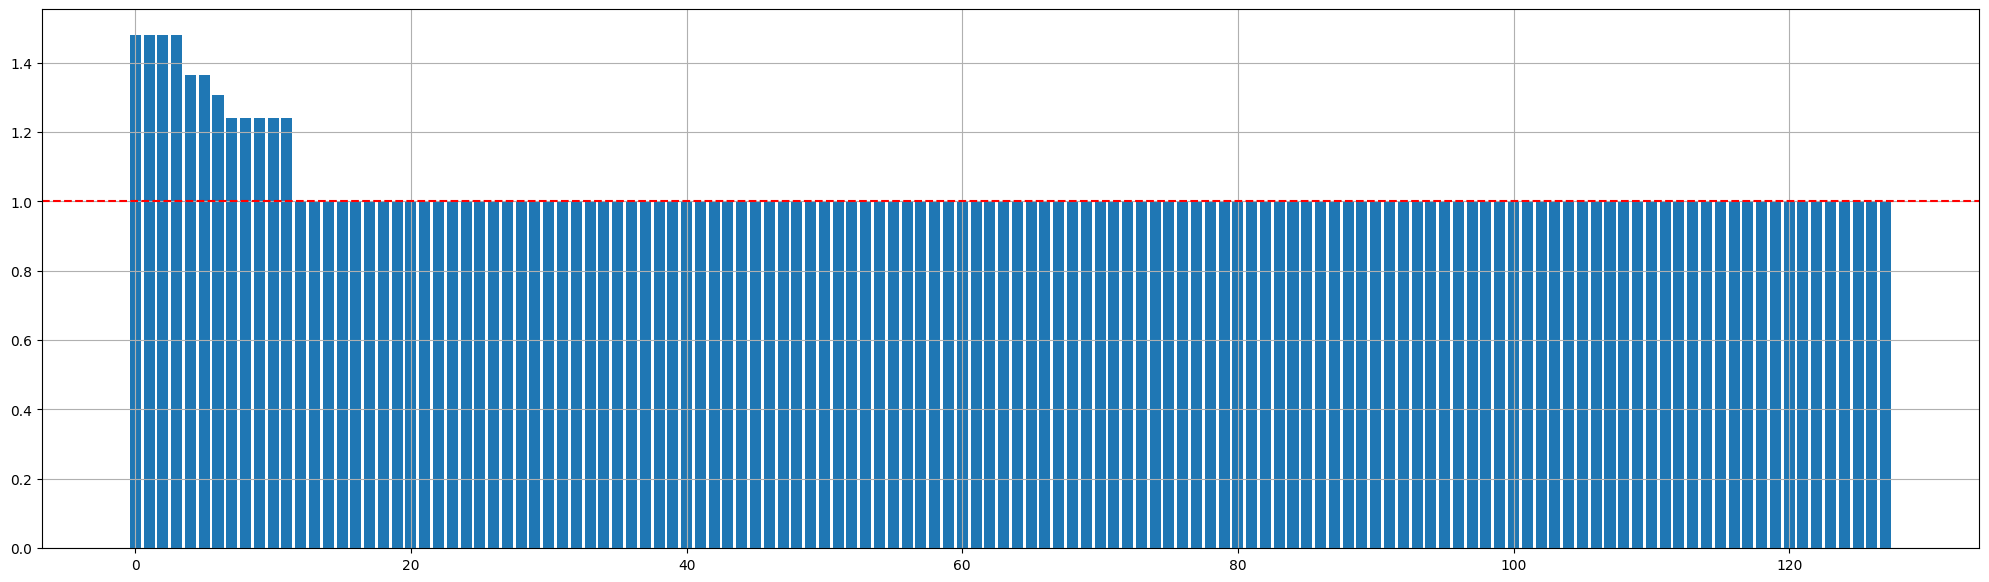

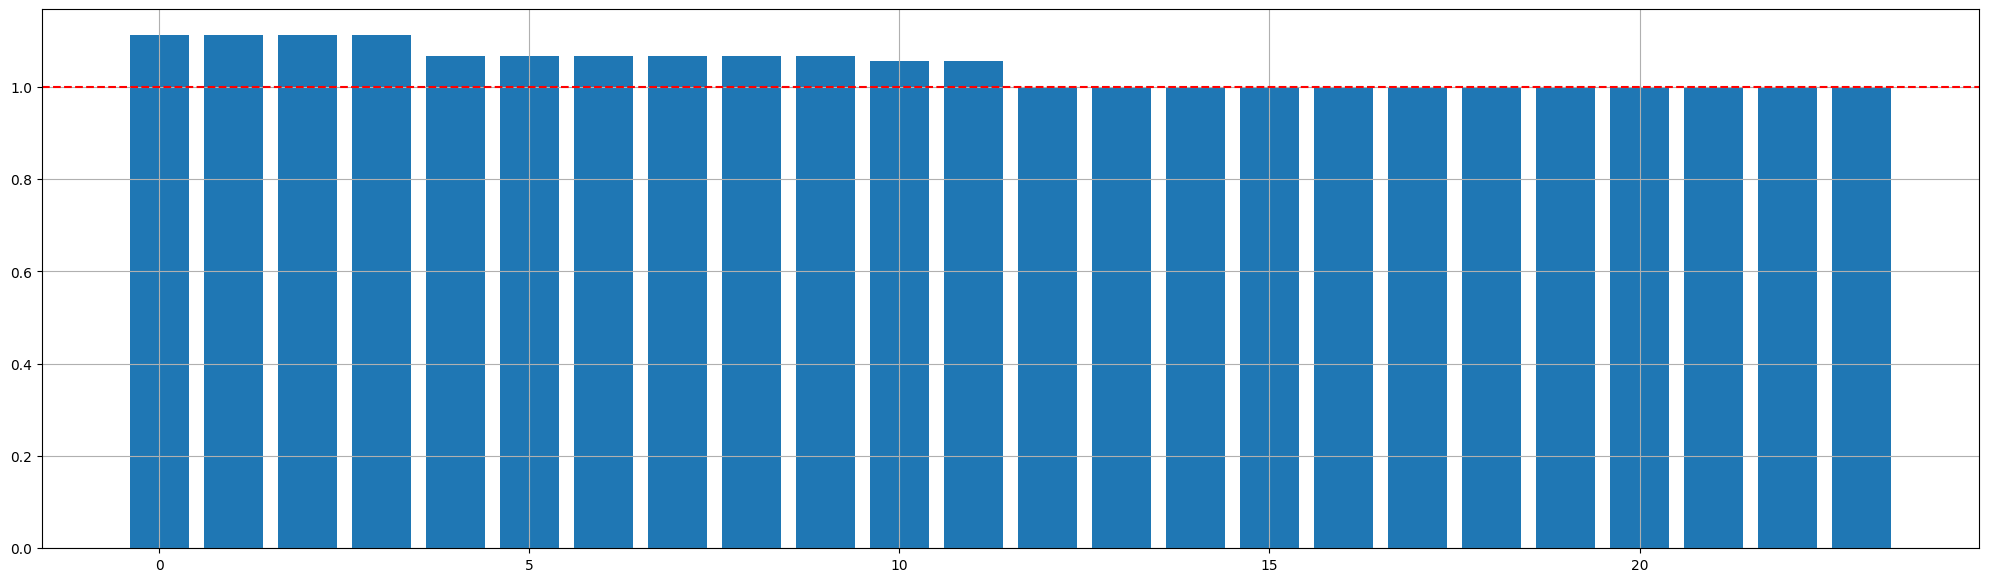

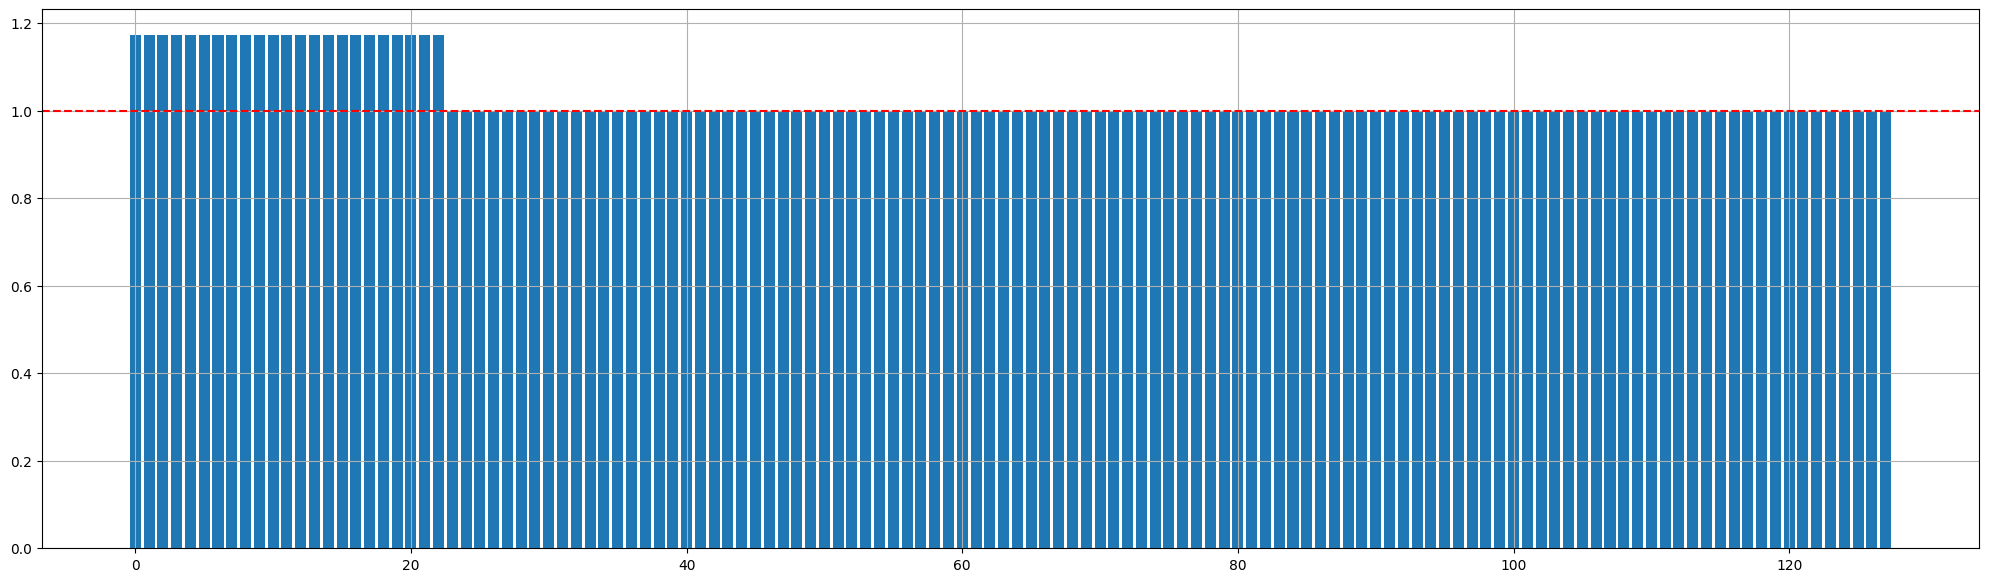

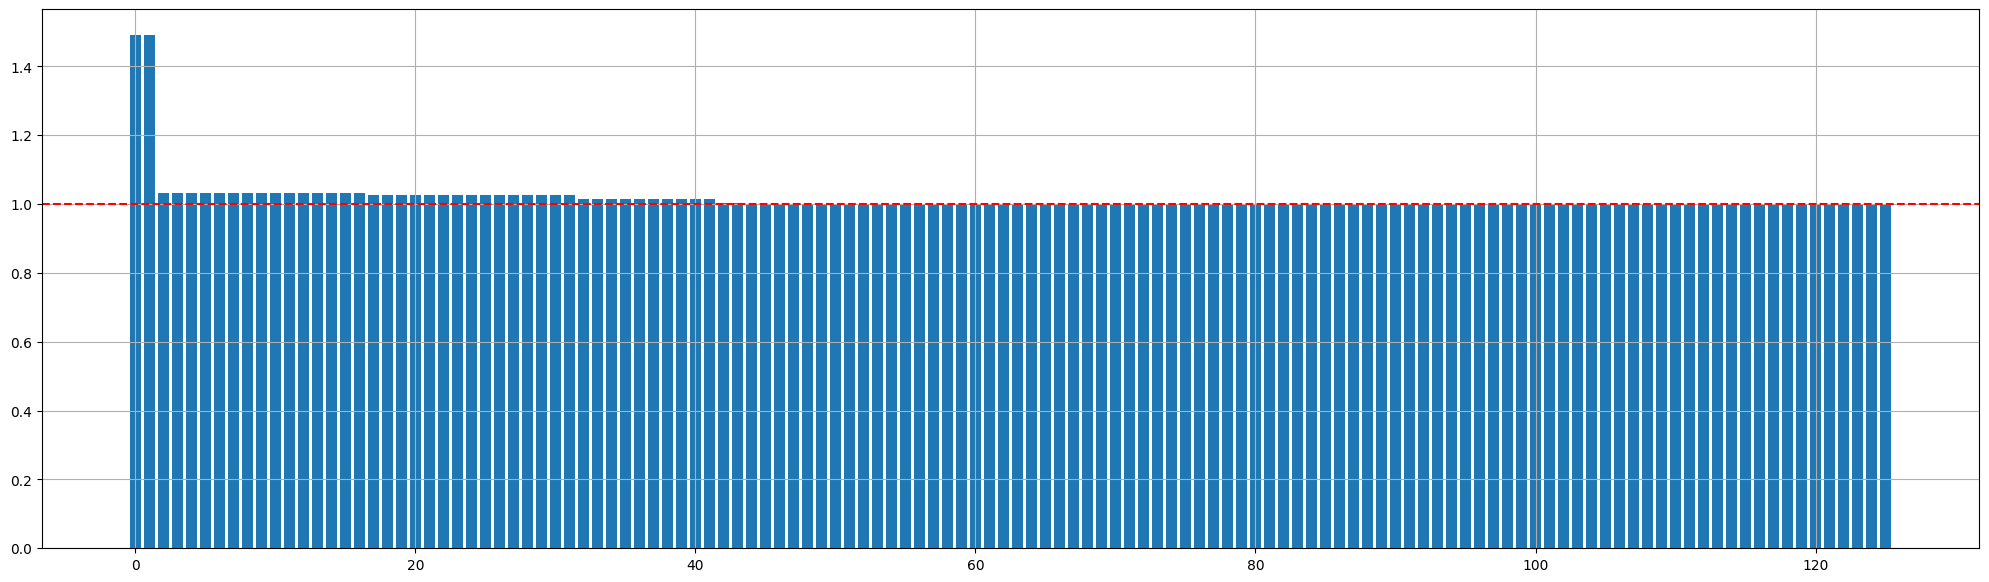

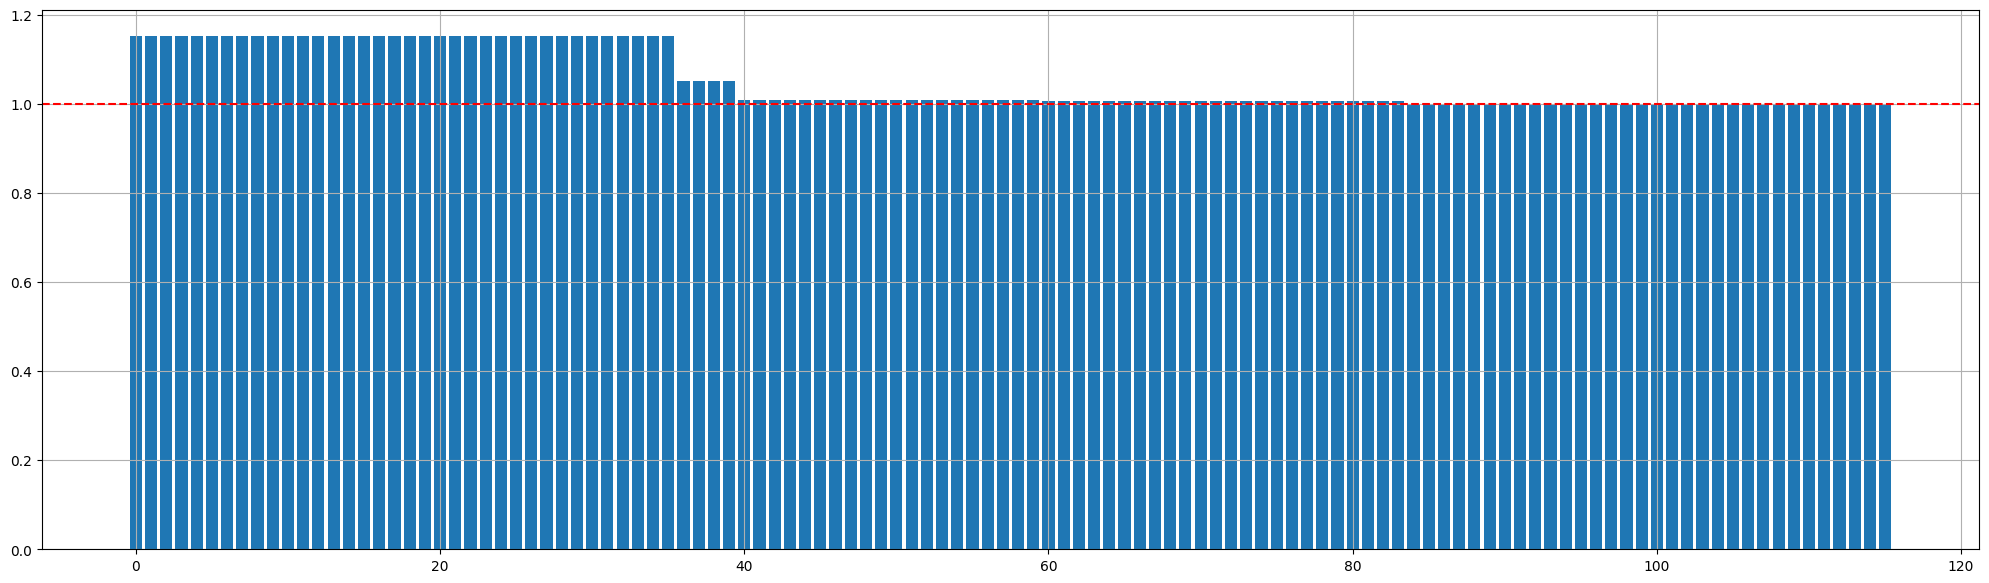

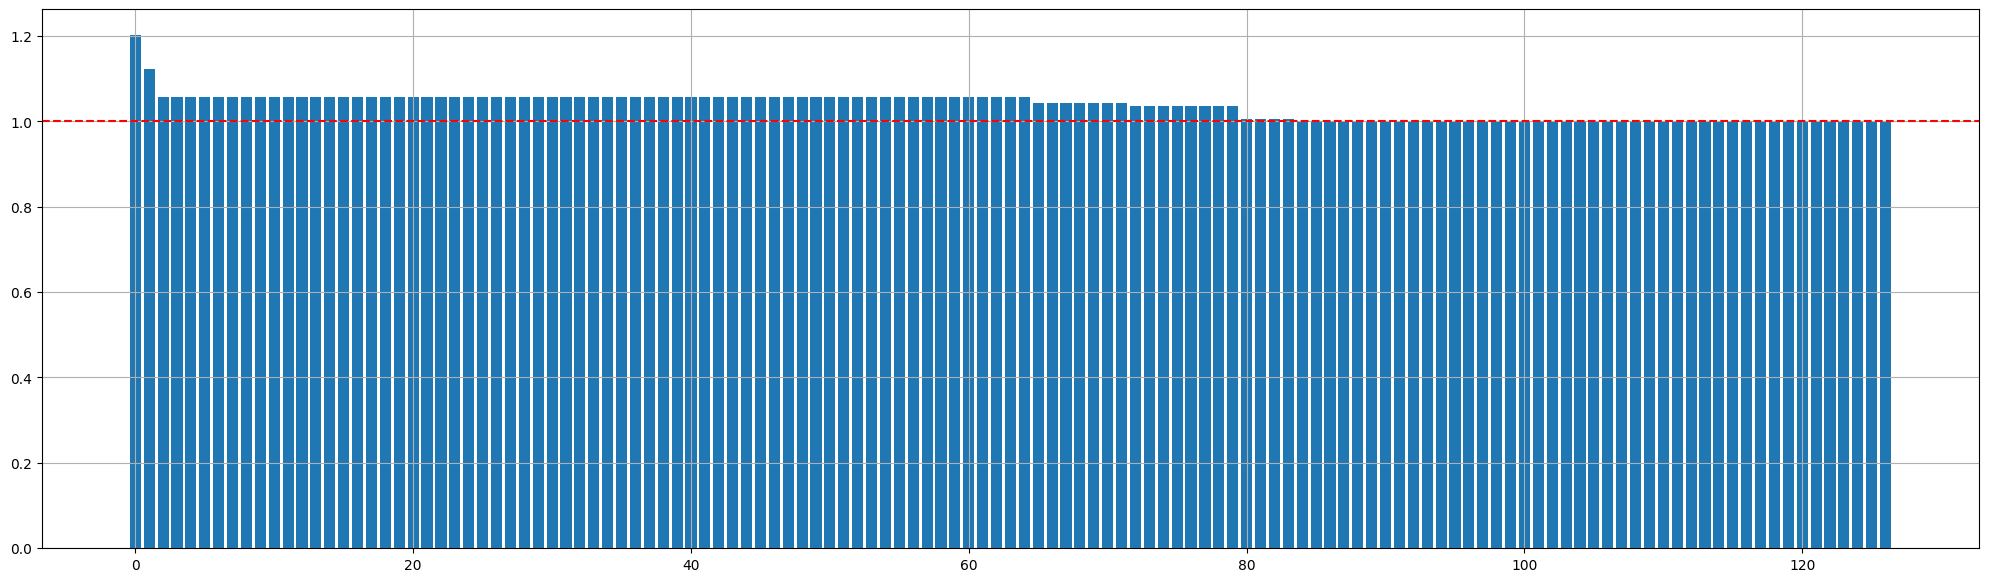

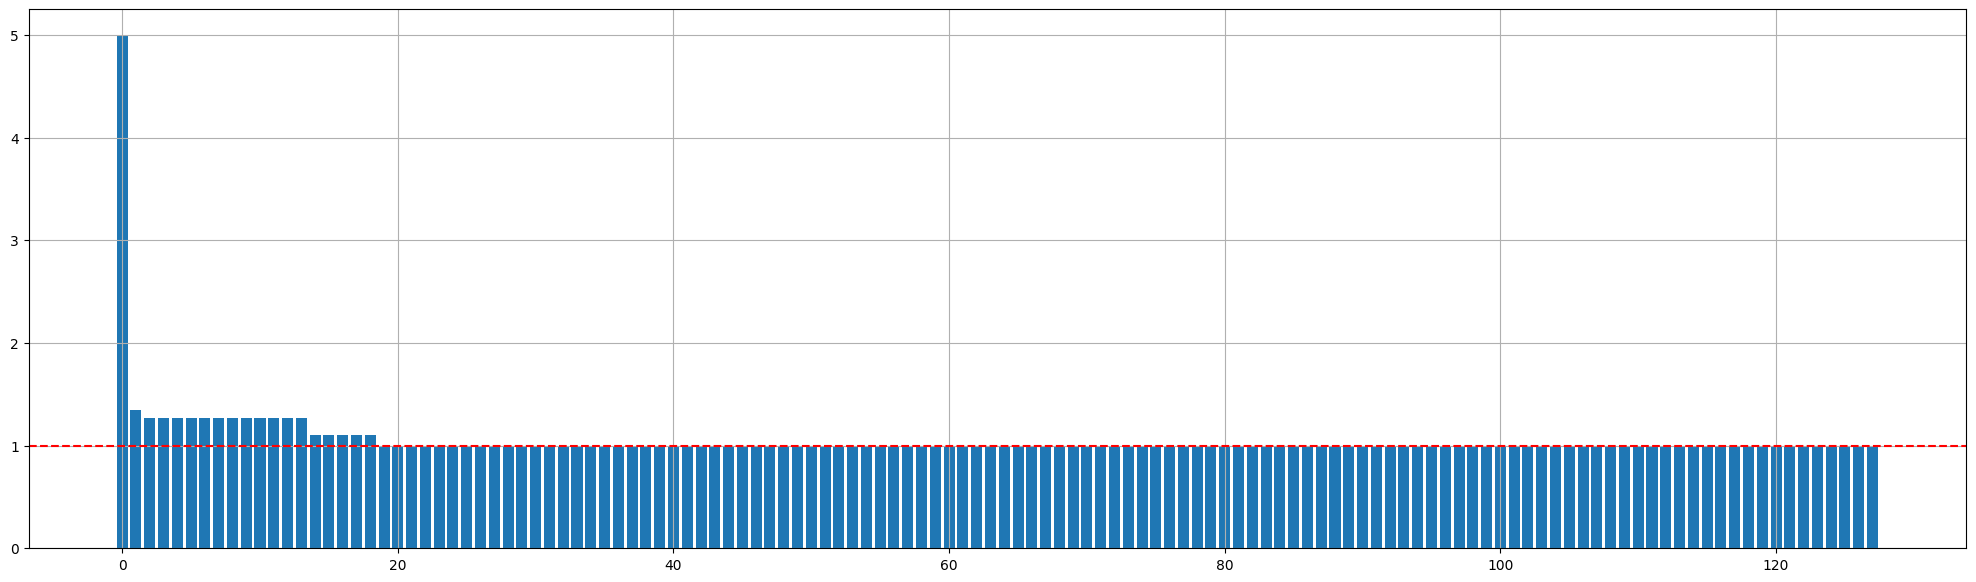

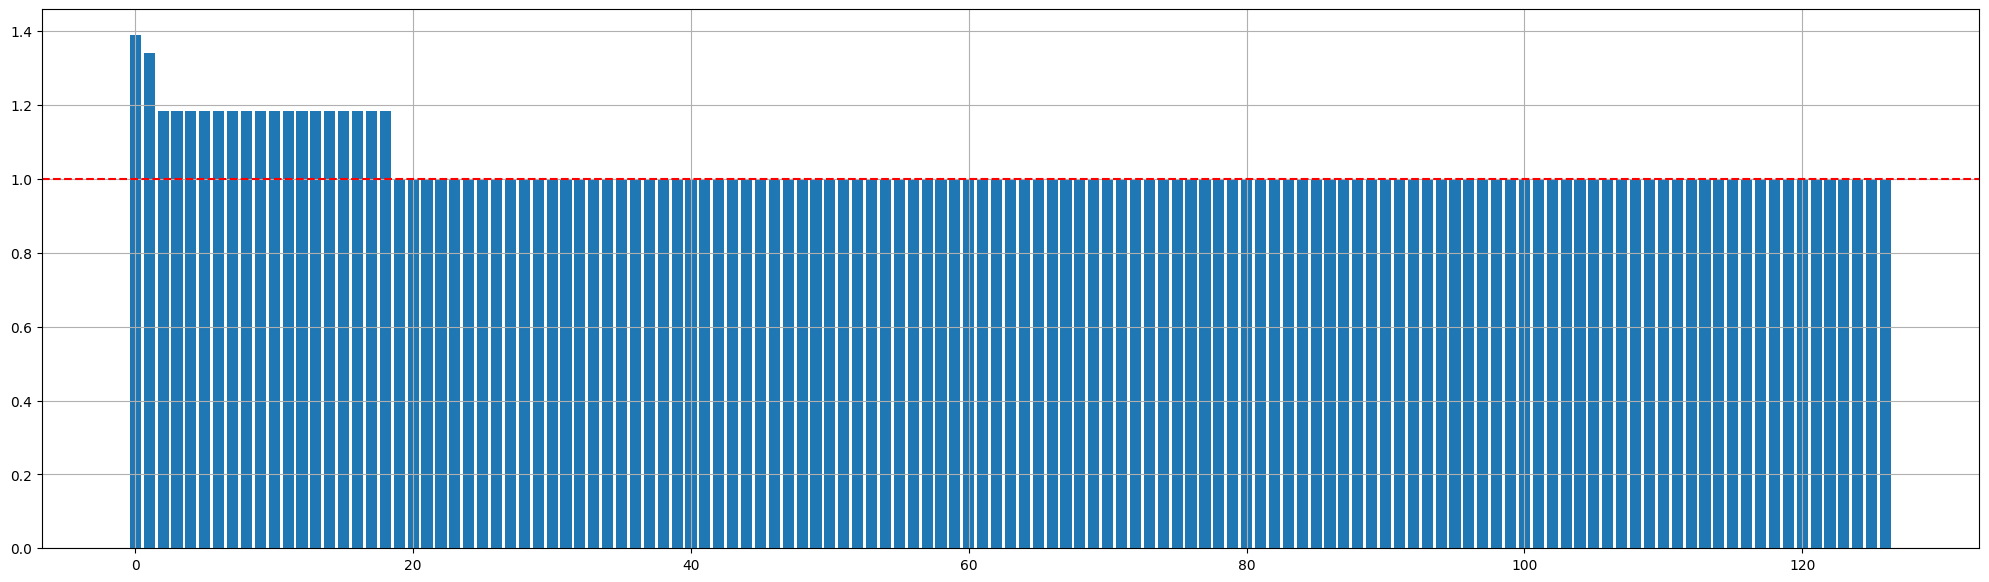

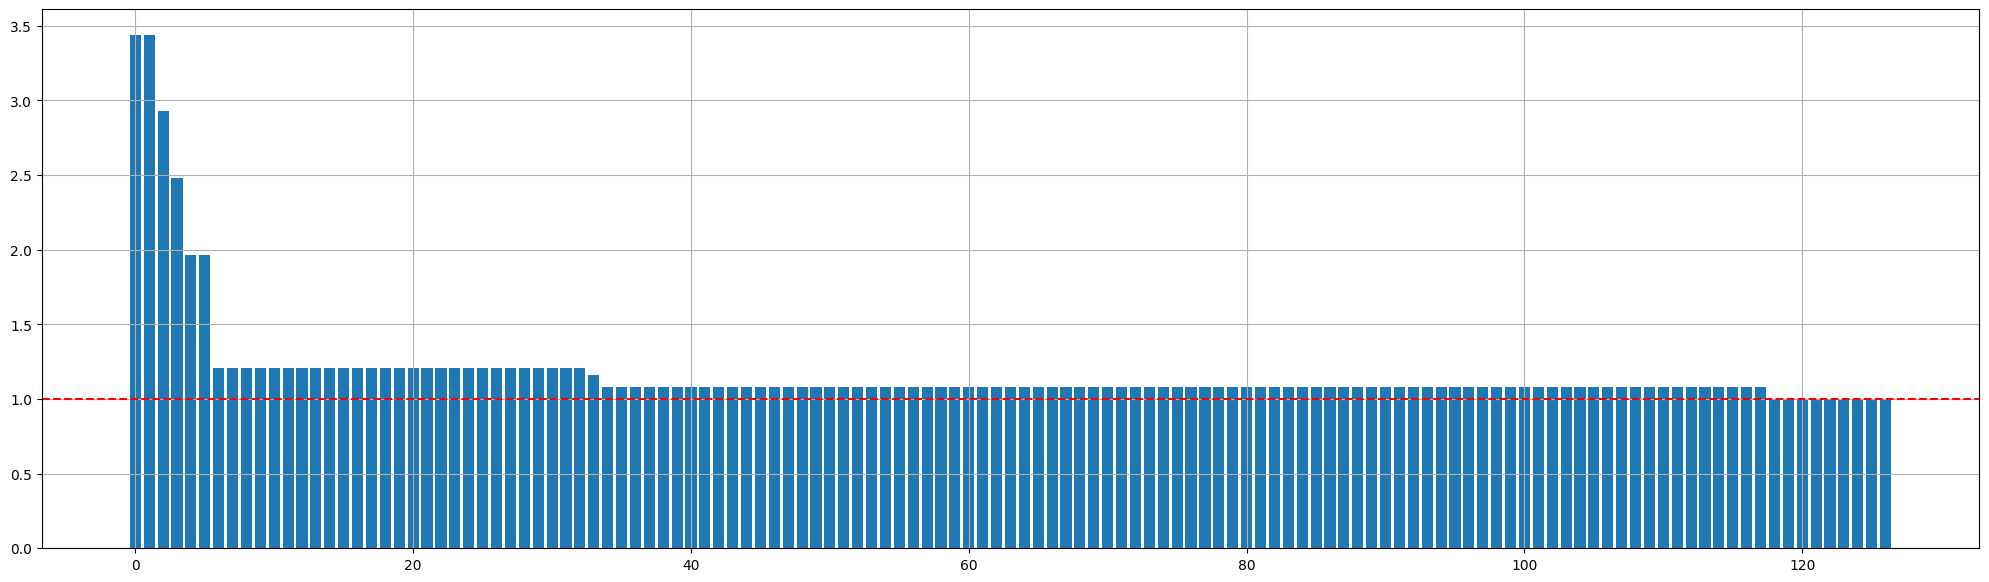

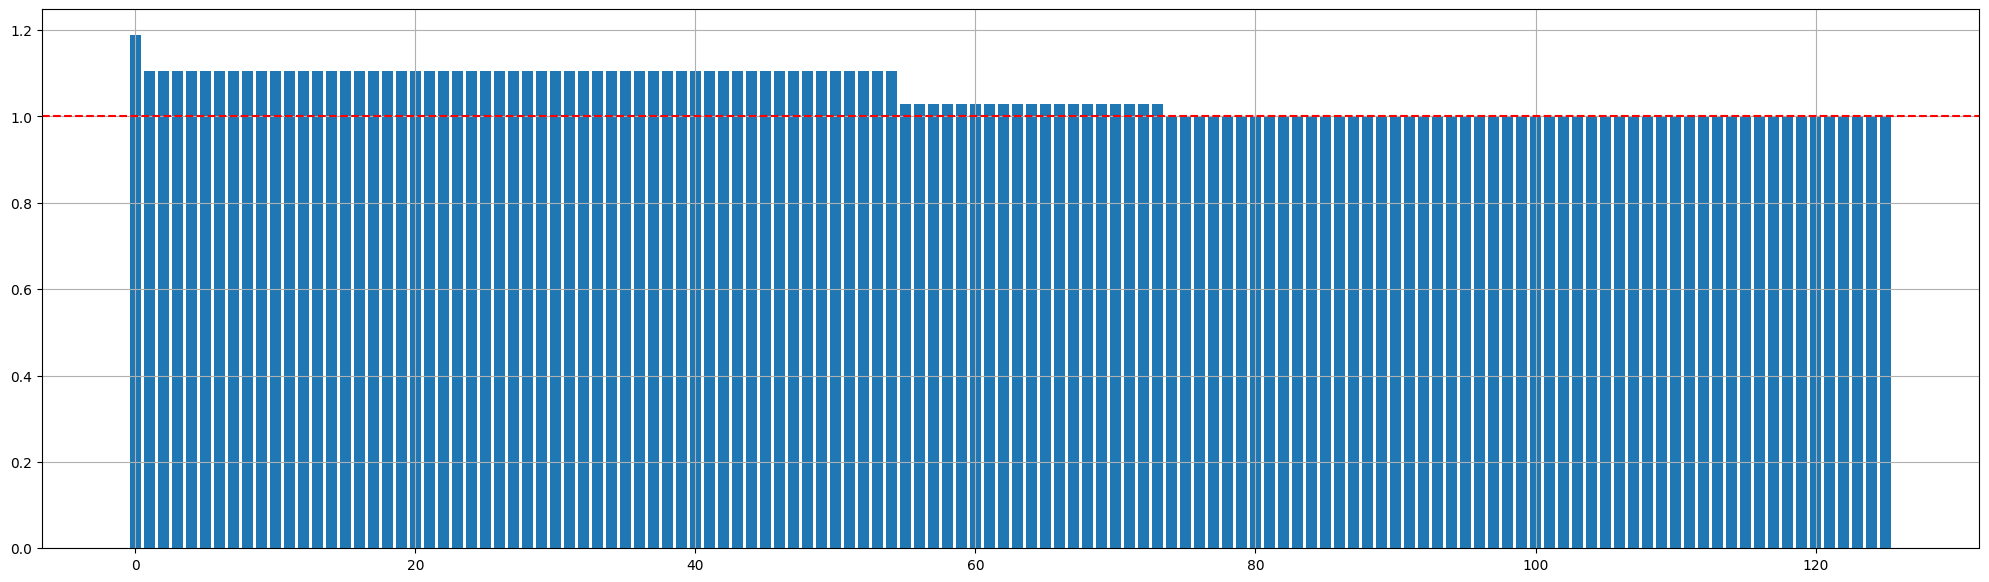

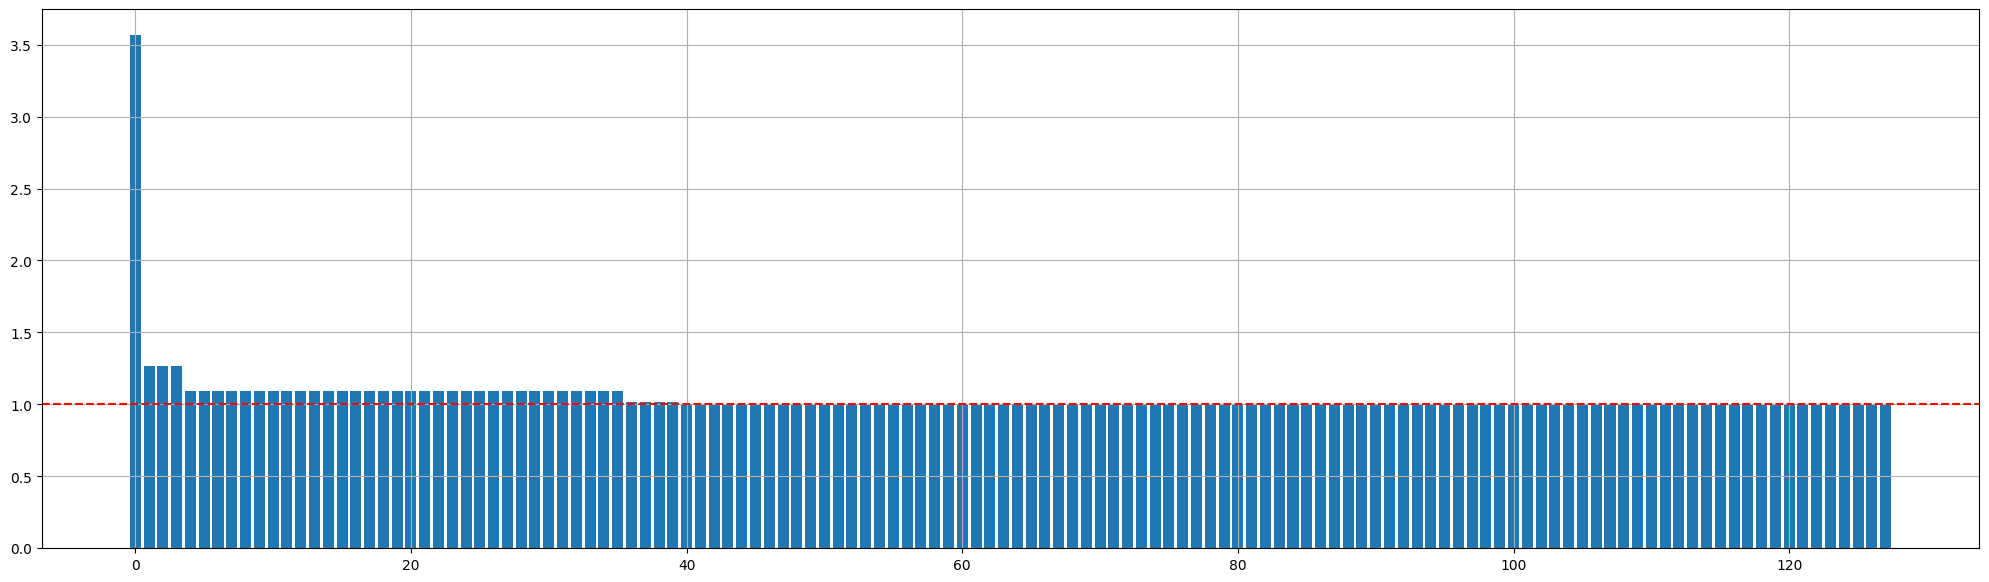

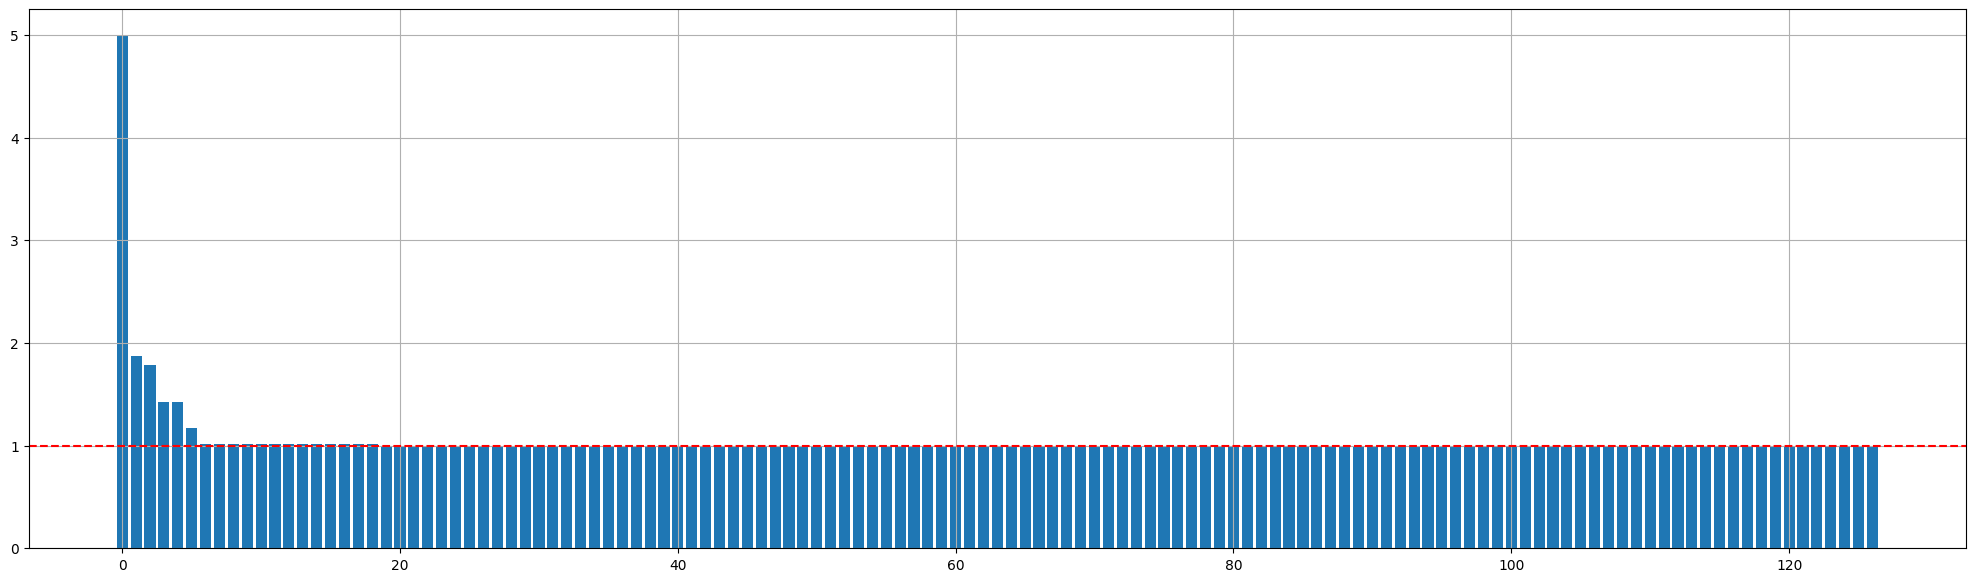

In [28]:
for task in values_new:
    if(len(values_new[task]) > 0):
        y = []
        acc = values_new[task][0]
        for x in values_new[task]:
            if(x < acc):
                acc = x
            #y.append(acc/min(values[task]))
            if(x/min(values_new[task]) > 5):
                y.append(5)
            else:
                y.append(x/min(values_new[task]))
        plt.figure(figsize=(25, 7))
        plt.axhline(y=1, color='r', linestyle='--')
        plt.bar(np.arange(len(y)), y)
        plt.grid()
        plt.show()